# **Deliverable 4: MRI Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 25–28** (Weeks 10–11) of the course. You will explore the complete physics foundation underlying Magnetic Resonance Imaging — from spin relaxation and tissue contrast through spatial encoding, pulse sequences, and advanced techniques.

Upon successful completion, you will be able to:
1. **Analyze** T1 and T2 relaxation dynamics and explain how TR and TE determine image contrast.
2. **Design** MRI spatial encoding schemes using gradient fields and describe k-space filling strategies.
3. **Compare** gradient echo, spin echo, fast spin echo, and inversion recovery pulse sequences.
4. **Implement** MRI image reconstruction from k-space data using the Fourier transform.
5. **Evaluate** diffusion-weighted imaging for clinical applications (e.g., acute stroke detection).
6. **Identify and mitigate** common MRI artifacts and explain MRI safety hazards.

---

# Part 1: Relaxation, Contrast, and Timing Parameters

## Key Concepts

**T1 Relaxation (Spin-Lattice):** Recovery of longitudinal magnetization after RF excitation
- For a 90° pulse: $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$
- At $t=T_1$: about 63% recovery
- Short-T1 tissues (e.g., fat) recover faster and appear brighter on T1-weighted images

**T2 and T2* Relaxation:** Decay of transverse magnetization due to dephasing
- $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$
- $\frac{1}{T_2^*}=\frac{1}{T_2}+\frac{1}{T_2'}$
- T2* includes field inhomogeneity effects, so $T_2^* < T_2$

**Contrast Control via TR and TE:**
- Short TR + short TE → T1-weighted
- Long TR + long TE → T2-weighted
- Long TR + short TE → PD-weighted
- Avoid short TR + long TE (mixed/poor contrast)

**Contrast Agents:**
- Gadolinium shortens T1 and increases signal on T1-weighted imaging
- Enhancement helps identify vascularity, permeability, and blood-brain barrier disruption

## 1.1 Relaxation Physics and Tissue Contrast

### **Questions 1**
You are comparing two tissues in a 1.5 T MRI scan:
Tissue A: $T_1 = 600$ ms, $T_2 = 80$ ms and Tissue B: $T_1 = 1200$ ms, $T_2 = 100$ ms

- a) For a 90° pulse, compute $M_z/M_0$ at $t = 300$ ms and $600$ ms for both tissues.
- b) A short-TR sequence is used. Which tissue will appear brighter on T1-weighted imaging, and how do your values support that answer?
- c) At $TE = 80$ ms, compare transverse signal fractions $e^{-TE/T_2}$ for both tissues. Based on your calculations, would these tissues separate more strongly on T1-weighted or T2-weighted imaging?

### **Questions 2**
A brain MRI includes CSF, white matter, and fat. Assume approximate values:

CSF: $T_1 = 4000$ ms, $T_2 = 2000$ ms, White matter: $T_1 = 600$ ms, $T_2 = 80$ ms, Fat: $T_1 = 250$ ms, $T_2 = 80$ ms

- a) Rank expected brightness for T1-weighted, T2-weighted, and PD-weighted imaging.
- b) Justify each ranking using the ideas of longitudinal recovery and transverse decay rather than memorization.
- c) A student suggests using short TR + long TE to maximize contrast. Critique this choice and explain what kind of mixed contrast it produces.


In [ ]:
# Question 1 - Answers
# a)
    # tissue A: T1 = 600 ms, T2 = 80 ms
        # T1 at t = 300 ms
            # Mz/M0 = 1 - e^-t/T1
            # Mz/M0 = 1 - e^-300 ms/600 ms
            # Mz/M0 = 1 - e^-0.5
            # Mz/M0 = 0.393
        # T1 at t = 600 ms
            # Mz/M0 = 1 - e^-t/T1
            # Mz/M0 = 1 - e^-600 ms/600 ms
            # Mz/M0 = 1 - e^-1
            # Mz/M0 = 0.632
    # tissue B: T1 = 1200 ms, T2 = 100 ms
        # T1 at t = 300 ms
            # Mz/M0 = 1 - e^-t/T1
            # Mz/M0 = 1 - e^-300 ms/1200 ms
            # Mz/M0 = 1 - e^-0.25
            # Mz/M0 = 0.221
        # T1 at t = 600 ms
            # Mz/M0 = 1 - e^-t/T1
            # Mz/M0 = 1 - e^-600 ms/1200 ms
            # Mz/M0 = 1 - e^-0.5
            # Mz/M0 = 0.393
# b)
    # Tissue A will appear brighter on T1-weighted imaging because Tissue A's T1
    # value of 600 ms is shorter than Tissue B's T1 value of 1200 ms which means
    # the tissue with the shorter T1 will recover faster and have more longitudinal
    # magnetization available to flip on to the transverse plane - yielding a 
    # stronger signal and appearing brighter. This can clearly be seen in the 
    # calculated values as well, wherein at 300 ms Tissue A has recovered to
    # 0.393 while Tissue B has only recovered to 0.221 - same at 600 ms were
    # A recovers to 0.632 and B is only at 0.393 (the recovery value A reaches
    # in half the time).
# c)
    # Tissue A: T1 = 600 ms, T2 = 80 ms
        # T2 at TE = 80 ms
            # = e^-TE/T2
            # = e^-80 ms/80 ms
            # = e^-1
            # = 0.368
    # Tissue B: T1 = 1200 ms, T2 = 100 ms
        # T2 at TE = 80 ms
            # = e^-TE/T2
            # = e^-80 ms/100 ms
            # = e^-0.8
            # = 0.449
    # with consideration to TE at 80 ms, Tissue B retains more transverse
    # magnetiziation and would therefore appear relatively brighter on a T2
    # weighted image.
    # in terms of strength of separation:
        # T1 recovery difference (TissueA_T1 - TissueB_T1):
            # at 300 ms: 0.393 - 0.221 = 0.172
            # at 600 ms: 0.632 - 0.393 = 0.239
        # T2 decay difference (TissueA_T2 - TissueB_T2):
            # at 80 ms: 0.449 - 0.368 = 0.081
    # based on these difference values, the separation is larger for the T1
    # recovery values than the T2 decay values which means that these tissues
    # would separate more strongly on T1-weighted imaging than on T2-weighted.

# Question 2 - Answers
# a)
    # T1-wieghted imaging
        # based on the T1 values, fat has the shortest T1 (250 ms) which means it 
        # recovers the fastest and should appear the brightest. white matter T1 
        # (600 ms) sits in the middle and would yield intermediate brightness, 
        # CSF has a very long T1 (4000 ms) which means slow recovery and would therefore
        # appear the darkest.
            # Fat > White matter > CSF
    # T2-weighted imaging
        # because brightness follows how slowly transverse magnetization decays
        # long TR means long TE. CSF T2 value (2000 ms) is quite long meaning
        # it can retain a greater amount of signal and would apear the brightest.
        # White matter and fat both have the same T2 value of 80 ms which are
        # much shorter in comparison meaning they retain less signal and based
        # on the values given would be on par with eachother in terms of expected
        # brightness.
            # CSF >> Fat ≈ White matter
    # PD-weighted imaging
        # because long TR and short TE minimize both T1 and T2 weightings causing
        # contrast to reflect proton density, and with no proton density values
        # given we cannot rank the tissues from T1/T2 alone. We know that in
        # typical MRI images CSF shows up relatively bright because its PD value 
        # is close to pure water. white matter i would assume is lower as it is
        # not as mobile as CSF nor is it a fluid and its high content of myelin
        # means it would have a lower PD than gray matter (as the myelin is the
        # reason white matter appears darker than gray matter in PD images). 
        # however, fat is quite a dense tissue which means that you should have
        # a higher density of protons available that can contribute to the MRI 
        # signal causing it to appear brighter. so while fat and white matter 
        # have similar T2 values, based on these properties i think it is safe
        # to assume that fat would be brighter than white matter in a PD
        # weighted image.
            # CSF > Fat > White matter
# b)
    # T1-weighted imaging
        # T1 imaging works best with short TR and short TE, meaning it maintains
        # an emphasis on longitudinal recovery before the next RF pulse. with
        # this in mind, because fat has the shortest T1 time out of all of
        # the tissues given it means that it can regain Mz quickly following
        # excitation because it is able to recover faster. white matter would
        # also recover quickly (compared to CSF) but not as fast as fat, CSF
        # has the longest T1 time out of all of them so with a short TR it
        # would still be highly saturated and would not have as much recovered
        # longitudinal mangetization available compared to the other two.
            # Fat > White matter > CSF
    # T2-weighted imaging
        # T2 imaging parameters favour long TR and long TE, which allows full
        # T1 recovery to occur (long TR) and for T2 decay to create contrast (long TE)
        # this means that it maintains an emphasis on how much transverse 
        # magnetization survives until echo time. because CSF has a large T2
        # it means that at long TE it will lose a marginal amount of transverse
        # signal. white matter and fat have similar T2 values which are relatively
        # short which causes their transverse magnetization to decay at a greater
        # rate before the echo can be measured.
            # CSF >> Fat ≈ White matter
    # PD-weighted imaging
        # PD favours long TR and short TE to minimize the effects of T1/T2
        # weighting, the long TR ensures that most tissues ~fully recover
        # their longitudinal magnetizationa and the short TE ensures little
        # transverse decay occurs before readout - meaning brightness relies
        # on the 'true' density of hydrogen protons that are present rather
        # than rates of recovery/decay. so using this logic, because CSF
        # has the highest proton density out of the given tissues, it will
        # attenuate the most, followed by fat due to its dense structure and
        # high hydrogen content, followed by white matter who's protons are
        # covered by the myelin sheath insulation which limits the amount
        # they can interact with the MRI signal.
            # CSF > Fat > White matter
# c)
    # if the goal is to maximize one clean type of contrast i dont think it
    # would be a good choice. TR controls the T1 weighting of the tissue, a 
    # shorter TR means the system will have a strong T1 weighting. TE controls
    # the T2 weighting of the system, long TE means strong T2 weighing will 
    # be introduced. the student is wanting to use short TR and long TE 
    # because the effects of those choices is strong T1 and strong T2 you end
    # up with contrast that is being pushed in different directions because
    # TR and TE are effectively working against eachother and could partially
    # or completely cancel one out. the yielded T1/T2 weighted image would
    # be less clear to interpret where some tissues may be dark due to 
    # incomplete longitudinal recovery, others could be dark due to transverse
    # decay and some may have competing effects that impair clean separation 
    # of structures in the image. in the end you end up with a 'hybrid' 
    # contrast image that offers little benefit rather than just meaningfully
    # making TR/TE selections depending on the type of weighting you want
    # for the tissues you are imaging rather than focusing purely on contrast.
            

## 1.2 Relaxation Curve and Contrast Simulation

### **Coding Exercise 1**
Implement a simulation that compares longitudinal and transverse magnetization behavior across tissues.

Tasks:
1. Define tissue parameters (e.g., CSF, white matter, fat): $T_1$, $T_2$.
2. Plot $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$ over time after a 90° pulse.
3. Plot $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$ over time.
4. Simulate signal intensity under different $(TR,TE)$ choices:
   - T1-weighted: short TR / short TE
   - T2-weighted: long TR / long TE
   - PD-weighted: long TR / short TE
5. Summarize which tissue is brightest under each weighting and why.

**Helpful Note:** You may use the tissue values from **Questions 2** directly (CSF, white matter, fat). To review equations and interpretation, look back at **Lecture 25** (relaxation + TR/TE weighting) and the Part 1 key concepts above.

=== Coding Exercise 1: Relaxation and Contrast Simulation ===


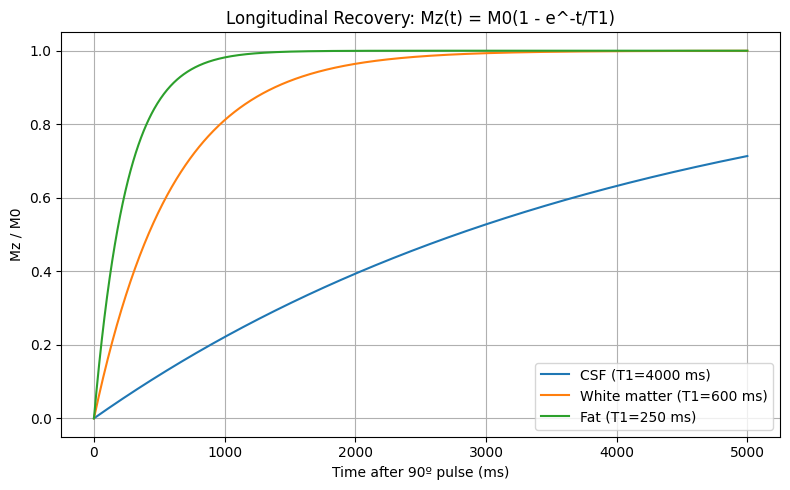

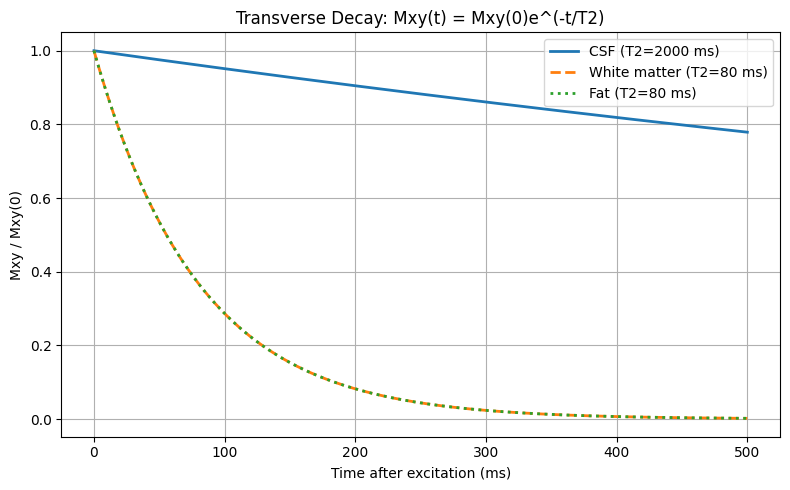


Simulated spin-echo signal intensities:


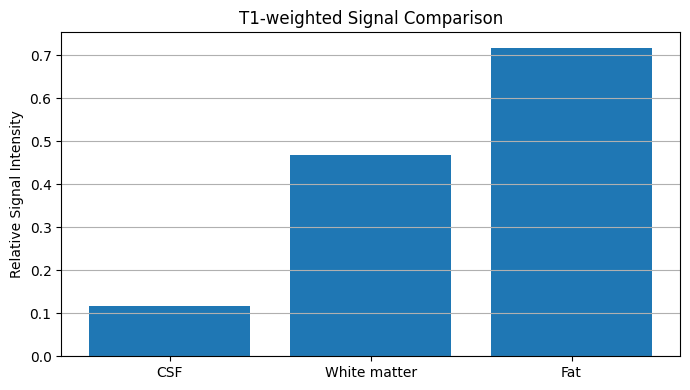

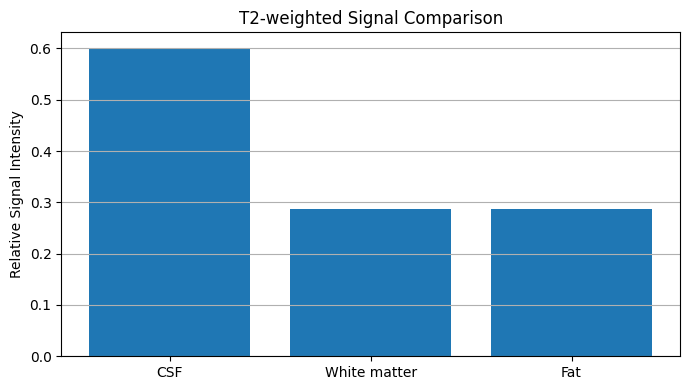

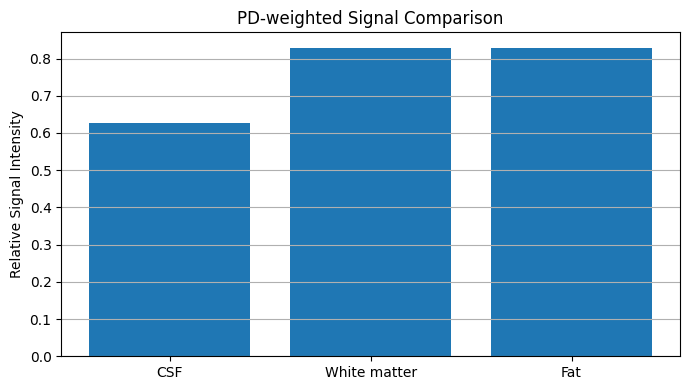


Brightness Rankings:
    T1-weighted: Fat(0.7168) > White matter(0.4687) > CSF(0.1166)
    T2-weighted: CSF(0.6013) > Fat(0.2865) > White matter(0.2861)
    PD-weighted: Fat(0.8290) > White matter(0.8280) > CSF(0.6274)

Interpretation:
T1-weighted:
  Fat is brightest because it has the shortest T1 & recovers longitudinal magnetization the fastest
  White matter is intermediate
  CSF is darkest because its large T1 value means it will experience minimal recovery at short TR

T2-weighted:
  CSF is brightest because it has the longest T2 value and it can retain transverse magnetization the longest
  Fat and white matter are darker because their similar T2 values are much shorter than CSF

PD-weighted:
  Long TR minimizes T1 and short TE minimizes T2
  This makes signals more similar though CSF remains relatively bright due to its high proton density
  While proton density was not given, assumptions for ranking was made based on the estimated proton density based on tissue type/properties

In [16]:
print("=== Coding Exercise 1: Relaxation and Contrast Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0

def mz_recovery(time_ms, t1_ms, m0=1.0):
    return m0 * (1 - np.exp(-time_ms / t1_ms))


def mxy_decay(time_ms, t2_ms, mxy0=1.0):
    return mxy0 * np.exp(-time_ms / t2_ms)


def spin_echo_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


# TODO 1: Define the tissue dictionary.
tissues = {
    "CSF": {"T1": 4000, "T2": 2000},
    "White matter": {"T1": 600, "T2": 80},
    "Fat": {"T1": 250, "T2": 80}
}

# TODO 2: Create time axes for T1 recovery and T2 decay.
t_recovery = np.linspace(0, 5000, 1000)
t_decay = np.linspace(0, 500, 1000)

# TODO 3: Compute Mz(t) and Mxy(t) for each tissue.
mz_curves = {}
mxy_curves = {}

for tissue, props in tissues.items():
    mz_curves[tissue] = mz_recovery(t_recovery, props["T1"], M0)
    mxy_curves[tissue] = mxy_decay(t_decay, props["T2"], M0)

# TODO 4: Plot the T1 recovery and T2 decay curves.
plt.figure(figsize=(8, 5))
for tissue in tissues:
    plt.plot(t_recovery, mz_curves[tissue], label=f"{tissue} (T1={tissues[tissue]['T1']} ms)")
plt.xlabel("Time after 90º pulse (ms)")
plt.ylabel("Mz / M0")
plt.title("Longitudinal Recovery: Mz(t) = M0(1 - e^-t/T1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

styles = {
    "CSF": {"linestyle": "-", "linewidth": 2},
    "White matter": {"linestyle": "--", "linewidth": 2},
    "Fat": {"linestyle": ":", "linewidth": 2},
}

plt.figure(figsize=(8, 5))
for tissue in tissues:
    plt.plot(
        t_decay,
        mxy_curves[tissue],
        label=f"{tissue} (T2={tissues[tissue]['T2']} ms)", 
        **styles[tissue]
    )

plt.xlabel("Time after excitation (ms)")
plt.ylabel("Mxy / Mxy(0)")
plt.title("Transverse Decay: Mxy(t) = Mxy(0)e^(-t/T2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# TODO 5: Define T1-, T2-, and PD-weighted (TR, TE) settings.
weightings = {
    "T1-weighted": {"TR": 500, "TE": 15},
    "T2-weighted": {"TR": 4000, "TE": 100},
    "PD-weighted": {"TR": 4000, "TE": 15}
}

# TODO 6: Compute the signal for each tissue under each weighting.
signals = {}

for weighting, params in weightings.items():
    tr = params["TR"]
    te = params["TE"]
    signals[weighting] = {}
    for tissue, props in tissues.items():
        sig = spin_echo_signal(tr, te, props["T1"], props["T2"])
        signals[weighting][tissue] = sig

print("\nSimulated spin-echo signal intensities:")
for weighting, tissue_signals in signals.items():
    names = list(tissue_signals.keys())
    values = list(tissue_signals.values())

    plt.figure(figsize=(7, 4))
    plt.bar(names, values)
    plt.ylabel("Relative Signal Intensity")
    plt.title(f"{weighting} Signal Comparison")
    plt.ylim(0, 1.05 * max(values))
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# TODO 7: Summarize the brightness ranking for each weighting.
print("\nBrightness Rankings:")
for weighting, tissue_signals in signals.items():
    ranked = sorted(tissue_signals.items(), key=lambda x: x[1], reverse=True)
    ranking_text = " > ".join([f"{name}({val:.4f})" for name, val in ranked])
    print(f"    {weighting}: {ranking_text}")

print("\nInterpretation:")
print("T1-weighted:")
print("  Fat is brightest because it has the shortest T1 & recovers longitudinal magnetization the fastest")
print("  White matter is intermediate")
print("  CSF is darkest because its large T1 value means it will experience minimal recovery at short TR")

print("\nT2-weighted:")
print("  CSF is brightest because it has the longest T2 value and it can retain transverse magnetization the longest")
print("  Fat and white matter are darker because their similar T2 values are much shorter than CSF")

print("\nPD-weighted:")
print("  Long TR minimizes T1 and short TE minimizes T2")
print("  This makes signals more similar though CSF remains relatively bright due to its high proton density")
print("  While proton density was not given, assumptions for ranking was made based on the estimated proton density based on tissue type/properties")

## 1.3 Contrast Agent and Field-Strength Analysis

### **Questions 3**
A lesion has pre-contrast $T_{1,0}=1000$ ms. After gadolinium injection, assume
$R_1=1/T_1 = 1/T_{1,0} + r_1[C]$, with $r_1 = 4\ \mathrm{L\,mmol^{-1}\,s^{-1}}$ and $[C]=0.2\ \mathrm{mmol/L}$.

- a) Compute post-contrast $T_1$ and predict how the lesion signal changes on a T1-weighted image.
- b) Explain why lesion enhancement often suggests blood-brain barrier disruption, and name one intracranial structure that enhances normally.
- c) Why must renal function be checked before gadolinium is given?

### **Questions 4**
At 3 T, many tissues show longer T1 values than at 1.5 T.

- a) Explain why a T1-weighted protocol copied directly from 1.5 T may not preserve the same contrast at 3 T.
- b) If you could change only one parameter first, would you adjust TR or flip angle? Defend your answer.
- c) Give one important benefit and one important drawback of moving from 1.5 T to 3 T for routine MRI.

In [ ]:
# Question 3 - Answers
# a)
    # T_1,0 = 1000 ms (1 s), r1 = 4 Lmmol^-1s^-1, [C] = 0.2 mmol/L
        # R1 = 1/T1 = 1/T_1,0 + r1[C]
            # R1 = 1/1 s + 4 Lmmol^-1s^-1(0.2 mmol/L)
            # R1 = 1.0 s^-1 + 0.8^ s-1
            # R1 = 1.8 s^-1
        # T1 = 1/R1
        # T1 = 1/1.8 s^-1
        # T1 = 556 ms
    # based on the above calculations the T1 value of the lesion drops from 1000 ms to
    # 556 ms. On T1-weighted images shortening of the T1 value means the tissue recovers
    # longitudinal magnetization faster between RF pulses so it produces a stronger signal
    # after the gadolinium injection the lesion should appear enhanced on T1-weighted
    # imaging based on these properties and calculations.
# b)
    # lesion enhancement often suggests BBB disruption because typically gadolinium
    # based contrast cannot freely leave the bloodstream and enter the cortical
    # parenchyma. so if a lesion enhances after gadolinium injection that could mean
    # either the BBB is disrupted or the lesion itself has abnormal vascularity that
    # is altering permeability - allowing the contrast agent to enter the interstitial
    # space where it can act on local T1 and increase T1-weighted signals. an example
    # of an intracranial structure that enhances normally would be the pituitary
    # gland due to its involvement with the endocrine system requiring high vascular
    # permeability in order to sense hormonal signals in the bloodstream, control
    # feedback loops and respond appropriately to maintain homeostasis.
# c)
    # renal function must be assessed prior to gadolinium injection because the kidneys
    # are responsible for clearing and filtering gadolinium from the bloodstream. if
    # renal function is impaired, the filtering of contrast out of the blood is also
    # delayed which causes it to remain in the body for an extended period of time
    # which increases the risk of complications occuring most importantly nephrogenic
    # fibrosis which is the accumulation of scar tissue in the nephron(s) severely 
    # impairing renal function and could lead to death depending on how severe the
    # patients renal impairment was prior to being injected with gadolinium.

#  Question 4 - Answers
# a)
    # because T1-weighted contrast is dependent on the amount of longitudinal recovery
    # occuring between RF pulses, if tissues have longer T1 values at 3T with the
    # same TR, all tissues will recover at a slower rate which alters the amount
    # of recovery occuring causing the relative difference between tissues to shift.
    # so using a protocol optimized for 1.5T may no longer be able to produce the same
    # degree of T1 separation at 3T - this can also affect the ability to discriminate
    # between lesions due to the altered contrast of the tissue caused by insufficient/
    # excessive T1-weighting depending on the primary sequence being used.
    # essentially just because the TR and flip angle are the same it does not mean that 
    # they correspond to the same saturation or recovery conditions once tissue T1 changes.
# b)
    # if only one parameter could be changed first, i would adjust TR first because
    # it directly controls the time alloted for longitudinal recovery which is the
    # main affector in T1-weighted imaging. since it is explicitly stated in the 
    # problem that the T1 values are longer at 3T the most direct plan of
    # attack is modifying the amount of recovery time, allowing a more straightforward
    # way to restore the desired contrast. while flip angle also affects saturation,
    # given the premise of the question, TR is the more fundamental control for 
    # modulating T1 recovery accross different field strengths.
# c)
    # an important benefit for moving from 1.5T to 3T would be a higher SNR because
    # at 3T you are getting more signal which can allow for higher spatial resolution,
    # thinner slices, faster scans and/or improved image quality. an important drawback
    # is that using 3T can lead to more RF heating constraints due to higher SAR
    # which can limit what sequences can be safely ran at the increased power level.



## 1.4 Contrast Agent and Field-Strength Simulation

### **Coding Exercise 2**
Build a compact simulation to study contrast-agent and field-strength effects.

Tasks:
1. Implement $\frac{1}{T_1}=\frac{1}{T_{1,0}}+r_1[C]$ and compute post-contrast $T_1$ for multiple concentrations.
2. Compare expected T1-weighted signal at 1.5 T and 3 T across a TR sweep.
3. Identify TR ranges that preserve lesion-to-background contrast.

**Helpful Note:** You can start from the values already given in **Question 3**, or choose your own reasonable values and state assumptions.

=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===


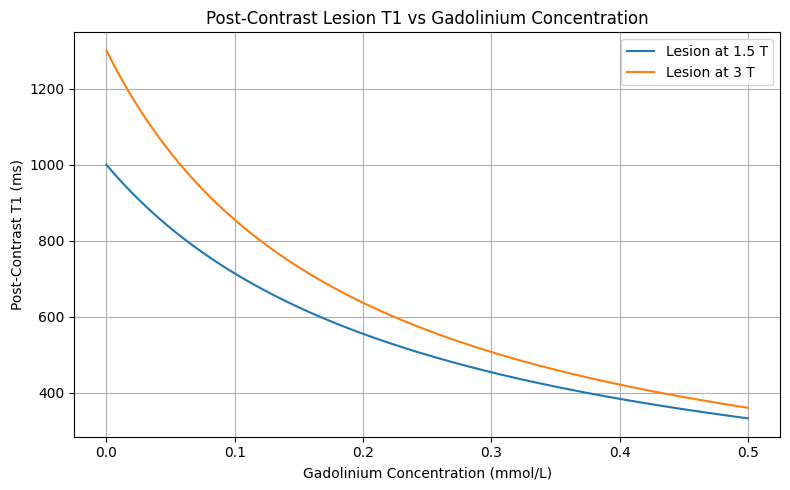

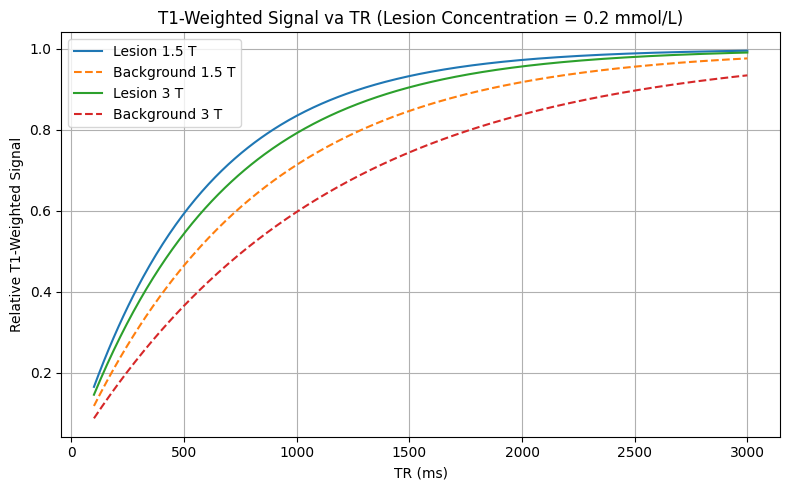

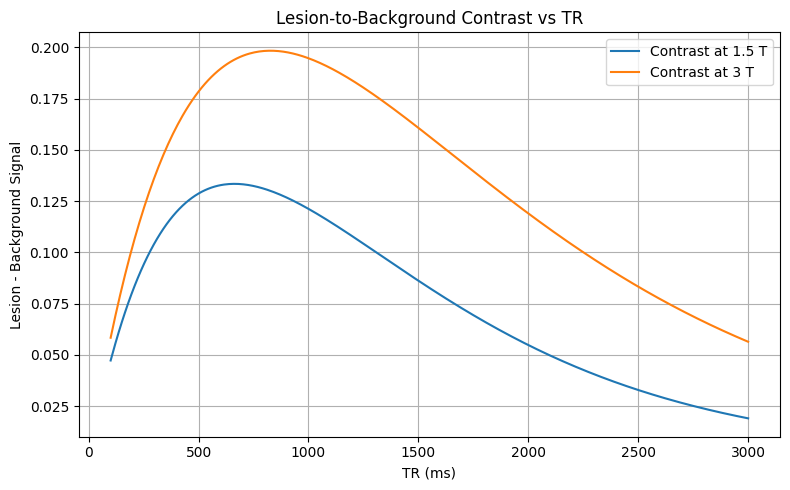


Post-Contrast Lesion T1 Values at Chosen Concentration:
    1.5 T: 555.6 ms
    3 T: 637.3 ms

Approximate TR Ranges with Strong Lesion-Background Contrast:
    1.5 T: about 318 ms to 1212 ms (>=80% of max contrast, max = 0.133)
    3 T: about 391 ms to 1517 ms (>=80% of max contrast, max = 0.198)

Note on 3T and SAR:
  3T MRI generally provides higher SNR but SAR is also higher
  This can limit how aggressively TR, flip angle and pulse design can be adjusted in practice


In [12]:
print("=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

r1 = 4.0  # L mmol^-1 s^-1

def post_contrast_t1(t1_pre_ms, concentration_mmol_per_l, relaxivity=r1):
    t1_pre_s = t1_pre_ms / 1000.0
    r1_pre = 1.0 / t1_pre_s
    r1_post = r1_pre + relaxivity * concentration_mmol_per_l
    return 1000.0 / r1_post


def t1_weighted_signal(tr_ms, t1_ms):
    return 1 - np.exp(-tr_ms / t1_ms)


# TODO 1: Define baseline T1 values at 1.5 T and 3 T.
T1_lesion_pre = {
    "1.5 T": 1000,
    "3 T": 1300
}

T1_background = {
    "1.5 T": 800,
    "3 T": 1100
}

# TODO 2: Create a gadolinium concentration array.
concentrations = np.linspace(0.0, 0.5, 200)

# TODO 3: Compute post-contrast lesion T1 for each field strength.
post_T1_curves = {}
for field in T1_lesion_pre:
    post_T1_curves[field] = post_contrast_t1(
        T1_lesion_pre[field],
        concentrations
    )

# TODO 4: Plot post-contrast lesion T1 versus concentration.
plt.figure(figsize=(8, 5))
for field in post_T1_curves:
    plt.plot(concentrations, post_T1_curves[field], label=f"Lesion at {field}")
plt.xlabel("Gadolinium Concentration (mmol/L)")
plt.ylabel("Post-Contrast T1 (ms)")
plt.title("Post-Contrast Lesion T1 vs Gadolinium Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# TODO 5: Create a TR sweep.
TR_values = np.linspace(100, 3000, 400)
chosen_concentration = 0.2

# TODO 6: Compute T1-weighted signal for lesion and background.
signals = {}

for field in T1_lesion_pre:
    lesion_T1_post = post_contrast_t1(T1_lesion_pre[field], chosen_concentration)
    background_T1 = T1_background[field]

    lesion_signal = t1_weighted_signal(TR_values, lesion_T1_post)
    background_signal = t1_weighted_signal(TR_values, background_T1)

    signals[field] = {
        "lesion_T1_post": lesion_T1_post,
        "background_T1": background_T1,
        "lesion_signal": lesion_signal,
        "background_signal": background_signal
    }

# TODO 7: Compute lesion-background contrast.
contrast = {}
for field in signals:
    contrast[field] = signals[field]["lesion_signal"] - signals[field]["background_signal"]

# TODO 8: Plot the signal or contrast versus TR.
plt.figure(figsize=(8, 5))
for field in signals:
    plt.plot(TR_values, signals[field]["lesion_signal"], label=f"Lesion {field}")
    plt.plot(TR_values, signals[field]["background_signal"], linestyle="--", label=f"Background {field}")
plt.xlabel("TR (ms)")
plt.ylabel("Relative T1-Weighted Signal")
plt.title(f"T1-Weighted Signal va TR (Lesion Concentration = {chosen_concentration} mmol/L)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for field in contrast:
    plt.plot(TR_values, contrast[field], label=f"Contrast at {field}")
plt.xlabel("TR (ms)")
plt.ylabel("Lesion - Background Signal")
plt.title("Lesion-to-Background Contrast vs TR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nPost-Contrast Lesion T1 Values at Chosen Concentration:")
for field in signals:
    print(f"    {field}: {signals[field]['lesion_T1_post']:.1f} ms")
print("\nApproximate TR Ranges with Strong Lesion-Background Contrast:")
for field in contrast:
    max_contrast = np.max(contrast[field])
    threshold = 0.8 * max_contrast
    valid_TR = TR_values[contrast[field] >= threshold]

    if len(valid_TR) > 0:
        TR_min = valid_TR[0]
        TR_max = valid_TR[-1]
        print(f"    {field}: about {TR_min:.0f} ms to {TR_max:.0f} ms "
              f"(>=80% of max contrast, max = {max_contrast:.3f})")
        
    else:
        print(f"    {field}: no TR range met the threshold")
# TODO 9: Add a short note about SAR at 3 T.
print("\nNote on 3T and SAR:")
print("  3T MRI generally provides higher SNR but SAR is also higher")
print("  This can limit how aggressively TR, flip angle and pulse design can be adjusted in practice")
# ...

---

# Part 2: Spatial Encoding, Gradients, and k-Space

## Key Concepts

**Magnetic Field Gradients:**
- Spatially varying field: $B(x)=B_0+G_xx$
- Position-dependent frequency: $\omega(x)=\gamma(B_0+G_xx)$

**Slice Selection:**
- Apply gradient during RF pulse
- Slice thickness: $\Delta z=\frac{BW}{\gamma G_z}$
- Thinner slices: increase $G_z$ or reduce RF bandwidth

**In-Plane Encoding:**
- Frequency encoding during readout gradient
- Phase encoding via gradient before readout
- Scan time is largely driven by number of phase-encode steps

**k-Space:**
- Spatial frequency domain of MRI data
- Image = Fourier transform of k-space
- Center of k-space controls contrast/intensity; edges control detail/resolution

## 2.1 Slice Selection and Encoding Calculations

### **Questions 5**
You apply a slice-selection gradient of $G_z=12\ \mathrm{mT/m}$ with RF bandwidth $BW=2.4\ \mathrm{kHz}$.

- a) Calculate slice thickness $\Delta z$ using $\gamma=42.58\ \mathrm{MHz/T}$.
- b) If $G_z$ doubles or BW halves, what happens to slice thickness in each case?
- c) Which change is usually the more practical way to make slices thinner, and what trade-off comes with it?
- d) Explain why thinner slices improve anatomical detail but make imaging harder from an SNR or motion standpoint.

### **Questions 6**
A 2D sequence uses $TR=2500$ ms, $N_{PE}=192$, and $NEX=2$.

- a) Compute total scan time.
- b) If $N_{PE}$ is reduced to 128, what is the new scan time?
- c) Compare reducing scan time by lowering NEX versus lowering $N_{PE}$. Which costs SNR, and which costs spatial resolution?


In [ ]:
# Question 5 - Answers
# a)
    # 𝛄 = 42.58 MHz/T (42.58 x 10^6 Hz/T), G_z = 12 mT/m (0.012 T/m), BW = 2.4 kHz (2400 Hz)
        # Δz = BW / 𝛄G_z
        # Δz = 2400 Hz / (42.58 x 10^6 Hz/T)(0.012 T/m)
        # Δz = 2400 Hz / 510960 Hz/m
        # Δz = 0.00470 m -> 4.70 mm
# b) 
    # slice thickness Δz is directly proportional to BW and inversely proportional
    # to G_z. so if you were to double G_z then Δz would reduce by half, if you
    # were to halve BW then Δz would also reduce by half - therefore both changes
    # would lead to a reduction in thickness Δz by half.
# c) 
    # usually modulation of the slice-selection gradient G_z is used as the more
    # practical way to make slices thinner. doubling G_z narrows the excited
    # slice without the reliance on a very narrow RF pulse bandwidth - this is
    # beneficial because if you narrow the RF bandwidth too much you will need
    # a longer RF pulse to supplement it.
    # however the stronger gradients that accompany increased G_z will also
    # increase the demand on the hardware being used to generate and process
    # them. stronger gradients also come with an increased risk for peripheral
    # nerve stimulation to occur because the gradients are being switched at
    # a faster rate which may impact results due to patient discomfort/motion.
# d)
    # thinner slices are able to improve anatomical detail because each voxel
    # is spanning less tissue in the slice direction which reduces partial-volume
    # averaging allowing smaller structures/features to be represented more 
    # accurately. in contrast, thinner slices make imaging harder because each
    # voxel contains fewer spins which means signal decreases and lower signal
    # means lower SNR.

# Question 6 - Answers
# a)
    # TR = 2500 ms (2.5 s), N_PE = 192, NEX = 2
        # ST = TR x N_PE x NEX
        # ST = 2.5 s x 192 x 2
        # ST = 2.5 s x 384
        # ST = 960 s -> 16 min
# b)
    # TR = 2.5 s, N_PE = 128, NEX = 2
        # ST = TR x N_PE x NEX
        # ST = 2.5 s x 128 x 2
        # ST = 2.5 s x 256
        # ST = 640 s -> 10 min 40 s
# c)
    # reducing scan time by lowering NEX works by reducing the number of signal
    # averages which lessens the time the patient spends in the scanner but
    # the trade off is lower SNR because averaging helps to improve SNR and 
    # lowering the number of averages means decreased NEX meaning noiser images.
    # reducing N_PE value decreases scan time by reducing the number of phase-encode
    # lines which will lower spatial resolution in the phase-encoding direction
    # it can also affect pixel size and reduce anatomical detail because the 
    # phase-encode lines are being sampled in wider berths which means fine 
    # details/nuances in the image could be missed.


## 2.2 k-Space Exploration and Fourier Reconstruction

### **Coding Exercise 3**
Use `IMG-0002-00001.dcm` to explore k-space concepts and reconstruction.

Tasks:
1. Load `IMG-0002-00001.dcm` and use the slice viewer to inspect the stack.
2. Move the slider to choose one slice from the middle portion of the stack that shows clear anatomy boundaries and relatively little empty background. Record the slice index.
3. Rerun the cell after choosing your slice so the analysis below uses that selected image.
4. Compute its 2D Fourier transform (k-space).
5. Visualize the image and k-space magnitude (log scale).
6. Reconstruct the image using the inverse Fourier transform.
7. Demonstrate the effect of:
   - Keeping only central k-space (low-pass behavior)
   - Removing central k-space (high-pass/edge emphasis)
   - Truncating high-frequency corners
8. Explain how these manipulations affect contrast and spatial detail.

**Helpful Note:** This exercise is a direct application of **Lecture 26**. Use the ideas that the center of k-space controls broad contrast and brightness, the outer regions control fine detail, and image reconstruction uses the 2D inverse Fourier transform.

In [13]:
%pip install ipywidgets
%pip install pydicom

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


=== Coding Exercise 3: k-Space and Reconstruction ===


HTML(value='<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion with clear anatomy …

IntSlider(value=10, continuous_update=False, description='Slice', layout=Layout(width='450px'), max=20)

HTML(value='')

Output()

Using slice index 10 for k-space analysis.


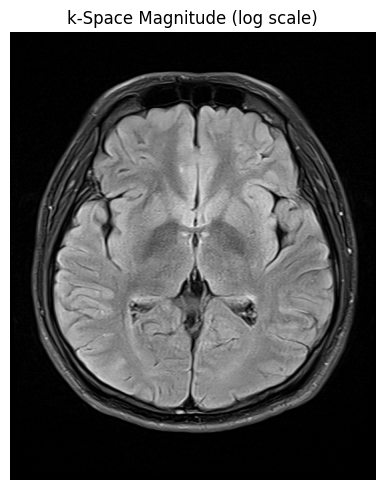

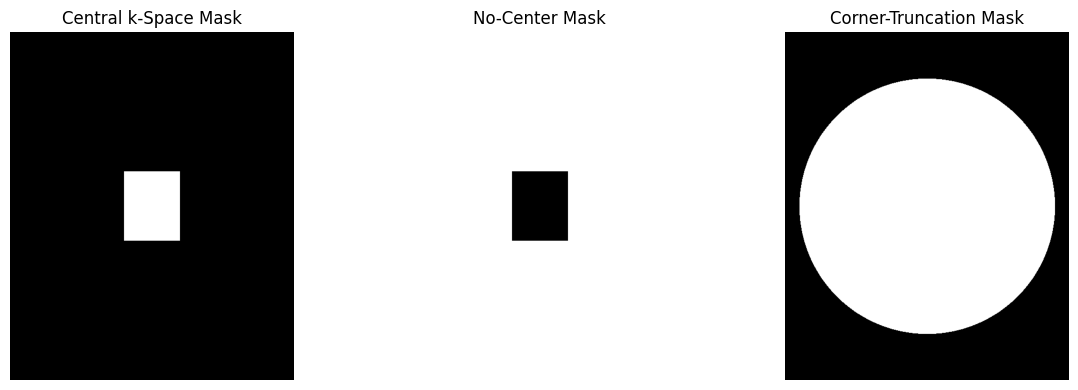

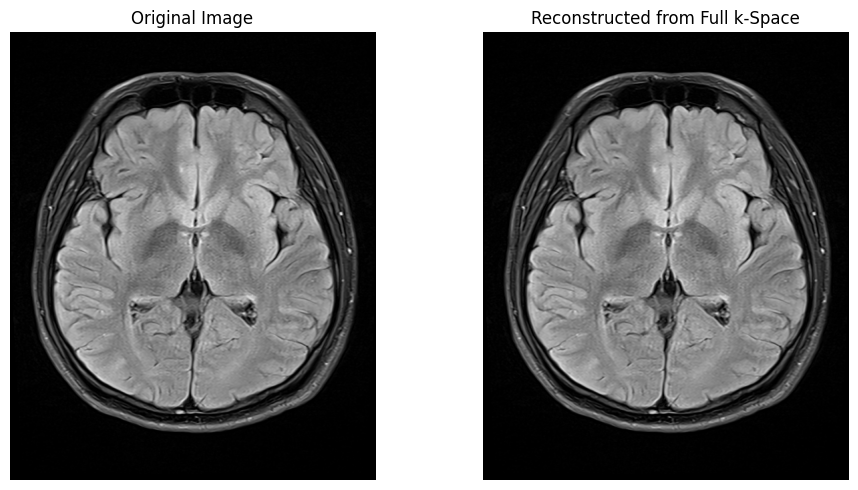

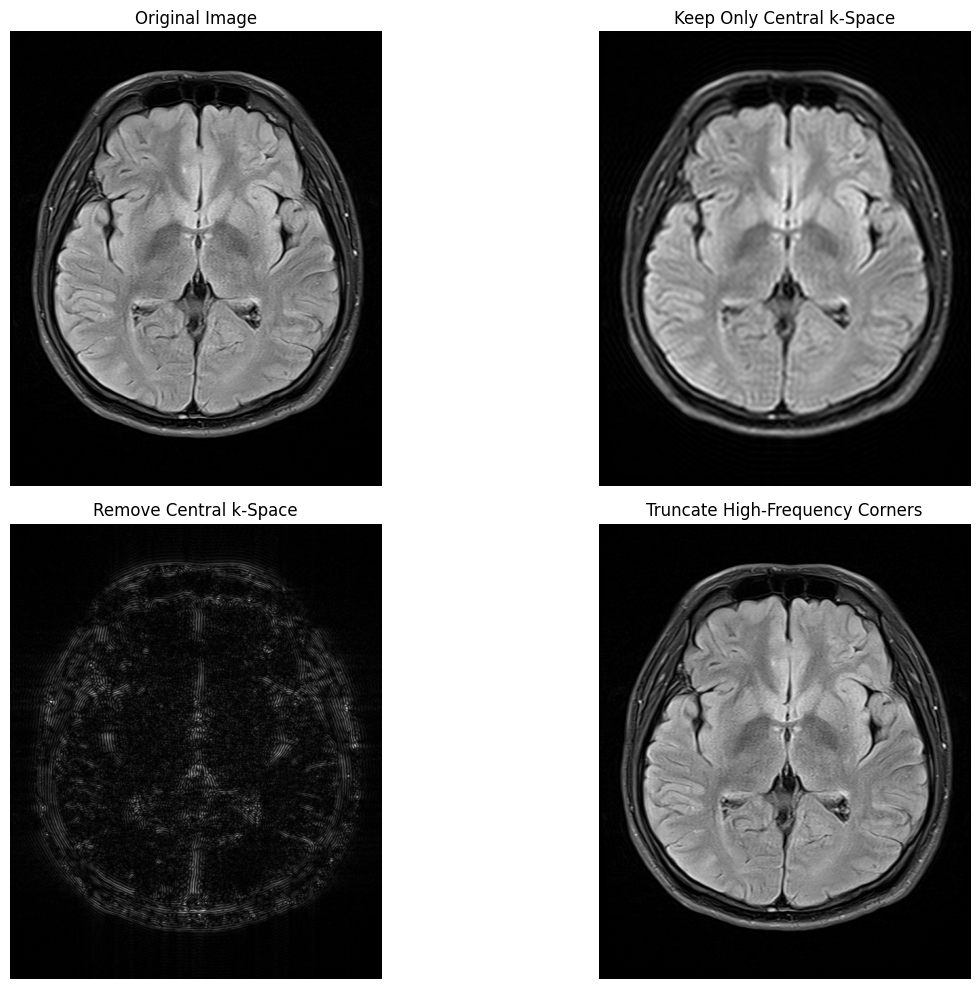


Interpretation:
1. Full inverse FFT reconstruction should closely match the original image.
2. Keeping only central k-space preserves broad intensity and contrast but blurs edges and fine detail.
3. Removing central k-space suppresses overall brightness structure and emphasizes edges/high-frequency content.
4. Truncating the outer corners removes some high spatial frequencies, so the image stays recognizable but loses sharpness.
5. The center of k-space mainly controls gross contrast and signal intensity, while the periphery contributes fine anatomical detail and edge definition.


In [13]:
print("=== Coding Exercise 3: k-Space and Reconstruction ===")

from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to your example DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("/Users/juliana/Desktop/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


def set_selected_slice(slice_idx: int):
    slice_idx = int(max(0, min(slice_stack.shape[0] - 1, slice_idx)))
    globals()["selected_slice_idx"] = slice_idx
    globals()["image"] = normalize_image(slice_stack[slice_idx])
    selection_message.value = (
        f"<b>Current selected slice:</b> {slice_idx}. "
        "If you change the slider, rerun this cell or Coding Exercise 4 to use the updated slice."
    )


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
default_slice_idx = slice_stack.shape[0] // 2
selected_slice_idx = int(globals().get("selected_slice_idx", default_slice_idx))
selection_message = widgets.HTML()


def render_slice(slice_idx: int):
    preview = normalize_image(slice_stack[slice_idx])
    plt.figure(figsize=(6, 6))
    plt.imshow(preview, cmap="gray")
    plt.title(f"IMG-0002-00001.dcm | slice {slice_idx}/{slice_stack.shape[0] - 1}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if slice_stack.shape[0] > 1:
    slice_slider = widgets.IntSlider(
        min=0,
        max=slice_stack.shape[0] - 1,
        step=1,
        value=selected_slice_idx,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )

    def on_slice_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        set_selected_slice(change["new"])

    slice_slider.observe(on_slice_change, names="value")
    display(widgets.HTML(
        "<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion "
        "with clear anatomy boundaries and minimal empty background."
    ))
    display(slice_slider)
    display(selection_message)
    display(widgets.interactive_output(render_slice, {"slice_idx": slice_slider}))
    set_selected_slice(slice_slider.value)
else:
    render_slice(default_slice_idx)
    set_selected_slice(default_slice_idx)

image = globals()["image"]
print(f"Using slice index {int(globals()['selected_slice_idx'])} for k-space analysis.")

# TODO: Compute 2D FFT and shift zero-frequency to center.
kspace = np.fft.fft2(image)
kspace_shifted = np.fft.fftshift(kspace)
kspace_mag_log = np.log1p(np.abs(kspace_shifted))

# TODO: Visualize the source image and log-magnitude k-space.
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("k-Space Magnitude (log scale)")
plt.axis("off")

plt.tight_layout()
plt.show()

# TODO: Reconstruct image with inverse FFT.
reconstructed = np.fft.ifft2(np.fft.ifftshift(kspace_shifted))
reconstructed = np.abs(reconstructed)
reconstructed = normalize_image(reconstructed)

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

def central_square_mask(shape, fraction=0.20):
    r, c = shape
    mask = np.zeros((r, c), dtype=np.float32)
    half_r = int((r * fraction) / 2)
    half_c = int((c * fraction) / 2)
    mask[crow - half_r:crow + half_r, ccol - half_c:ccol + half_c] = 1.0
    return mask
def remove_center_mask(shape, fraction=0.20):
    return 1.0 - central_square_mask(shape, fraction=fraction)

def truncate_corners_mask(shape, radius_fraction=0.45):
    r, c = shape
    yy, xx = np.ogrid[:r, :c]
    dist = np.sqrt((yy - crow) ** 2 + (xx - ccol) ** 2)
    max_radius = radius_fraction * min(r, c)
    mask = (dist <= max_radius).astype(np.float32)
    return mask

# TODO: Apply central-k-space, no-center, and corner-truncation masks.
center_mask = central_square_mask(image.shape, fraction=0.20)
no_center_mask = remove_center_mask(image.shape, fraction=0.20)
corner_trunc_mask = truncate_corners_mask(image.shape, radius_fraction=0.45)

kspace_center_only = kspace_shifted * center_mask
kspace_no_center = kspace_shifted * no_center_mask
kspace_corner_trunc = kspace_shifted * corner_trunc_mask

recon_center_only = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_center_only)))
recon_no_center = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_no_center)))
recon_corner_trunc = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace_corner_trunc)))

recon_center_only = normalize_image(recon_center_only)
recon_no_center = normalize_image(recon_no_center)
recon_corner_trunc = normalize_image(recon_corner_trunc)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(center_mask, cmap="gray")
plt.title("Central k-Space Mask")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(no_center_mask, cmap="gray")
plt.title("No-Center Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(corner_trunc_mask, cmap="gray")
plt.title("Corner-Truncation Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed from Full k-Space")
plt.axis("off")

plt.tight_layout()
plt.show()

# TODO: Compare reconstructions and discuss contrast/detail differences.
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(recon_center_only, cmap="gray")
plt.title("Keep Only Central k-Space")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(recon_no_center, cmap="gray")
plt.title("Remove Central k-Space")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(recon_corner_trunc, cmap="gray")
plt.title("Truncate High-Frequency Corners")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("1. Full inverse FFT reconstruction should closely match the original image.")
print("2. Keeping only central k-space preserves broad intensity and contrast but " \
"blurs edges and fine detail.")
print("3. Removing central k-space suppresses overall brightness structure and " \
"emphasizes edges/high-frequency content.")
print("4. Truncating the outer corners removes some high spatial frequencies, " \
"so the image stays recognizable but loses sharpness.")
print("5. The center of k-space mainly controls gross contrast and signal " \
"intensity, while the periphery contributes fine anatomical detail and edge " \
"definition.")

## 2.3 Gradient History and k-Space Trajectory

### **Questions 7**
Consider Cartesian k-space sampling in a 2D GRE sequence.

- a) Explain why each TR usually acquires one readout line but a different $k_y$ value.
- b) Relate k-space spacing to FOV and k-space extent to spatial resolution.
- c) Why does undersampling in the phase-encode direction produce wrap-around?

### **Questions 8**
Compare Cartesian and non-Cartesian trajectories such as radial or spiral.

- a) Which trajectories oversample the center of k-space, and why can that help with motion?
- b) What extra reconstruction challenge appears when sampling is non-uniform?
- c) Give one clinical situation where a radial or spiral trajectory could be preferred, and justify your choice.


In [ ]:
# Question 7 - Answers
# a)
    # each TR acquires a different k_y value because the readout gradient (Gx)
    # is applied during signal acquisition which encodes one full line in kx
    # before readout occurs, a phase-encoding gradient (Gy) is applied which
    # sets the ky position - therefore each TR applies a different Gy amplitude
    # that shifts to a different ky line in k-space and this works to fill 
    # k-space line by line accross multiple TRs until the scan is complete.
# b)
    # k-space spacing and FOV share an inverse relationship, as FOV increases
    # spacing decreases - likewise as spacing increases FOV decreases, suggesting
    # that the sampling density of k-space (Δk) determines the FOV.
    # in terms of the extent of k-space and spatial resolution, the maximum
    # extent of k-space (2k_max) has a ~proportional relationahip with 
    # ressolution - the larger k_max is the higher your resolution and ability
    # to see finer detail, the smaller k_max is the blurrier your image.
# c)
    # if you undersample in k_y, Δk_y will increase which causes the effective
    # FOV in the phase-encode direction to decrease. however, the actual
    # size of the object remains unchanged and with the now reduced FOV
    # parts of the object will lie outside of it - because MRI assumes the
    # image is periodic, signals coming from the object lying outside the 
    # FOV get aliased back into the image causing wrap-around.

# Question 8 - Answers
# a)
    # the trajectories that oversample the center of k-space are radial and
    # spiral trajectories. reason being is that every readout passes thru or
    # near the center which leads to the repeated sampling of low-frequency
    # information. in terms of how they could help with motion, because the
    # center controls contrast and bulk structure, repeated sampling will
    # make the information within more robust causing motion artifacts to
    # get spread out and yield less coherent ghosting - allowing the system
    # to capture the low-frequency information which defines the overall 
    # contrast of the image.
# b)
    # when sampling is non-uniform the grid is not uniform which impairs fft
    # attempts. in order to rectify this you must perform gridding/interpolation
    # which maps the non-uniform data to a uniform cartesian grid, this must
    # be done before applying the fft which makes reconstruction more
    # computationally complex compared to if you had uniform sampling to begin
    # with.
# c)
    # radial/spiral imaging would be preferred in motion-prone imaging like
    # cardiac, abdominal or pediatric applications. for example in cardiac
    # imaging, because the heart is constantly beating and you cannot just
    # stop it while you scan the patient - like you can with breath-hold for 
    # breathing motion - radial imaging would be preferred because by
    # oversampling the center of k-space you preserve contrast in spite of 
    # motion and they will render as mild streaking rather than severe ghosting


## 2.4 Undersampling and Acquisition Efficiency

### **Coding Exercise 4**
Reuse the same selected slice from `IMG-0002-00001.dcm` to compare encoding choices and acquisition efficiency.

Tasks:
1. Use the same slice index selected in Coding Exercise 3. If you change the slider in Coding Exercise 3, rerun this cell so it uses the updated slice. If you did not run Exercise 3, the middle slice will be used by default.
2. Implement scan-time estimates for multiple protocol options (TR, N_PE, NEX, ETL).
3. Create at least two undersampling patterns (for example, uniform skip and central-weighted retention).
4. Reconstruct from each sampling pattern and compare artifact severity.
5. Summarize the best speed-vs-quality option for a chosen clinical objective.

In [ ]:
#Run this cell to verify the slice viewer is working for the next coding exercises.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to correct DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("/Users/juliana/Desktop/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
slice_idx = int(globals().get("selected_slice_idx", slice_stack.shape[0] // 2))
slice_idx = max(0, min(slice_stack.shape[0] - 1, slice_idx))
reference_image = normalize_image(slice_stack[slice_idx])

print(f"Using slice index {slice_idx} for encoding comparisons.")


Using slice index 10 for encoding comparisons.


=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===

Estimated Scan Times:
Full sampling, ETL=1, NEX=1: 1680.0 s (28.00 min)
Full sampling, ETL=1, NEX=2: 3360.0 s (56.00 min)
Faster ETL=2: 840.0 s (14.00 min)
Reduced phase encodes: 1175.0 s (19.58 min)

Undersampling Summary:
Uniform Mask: retained 50.0% of k-space lines, acceleration ~2.00x, NRMSE = 0.5750
Central-Weighted Mask: retained 43.8% of k-space lines, acceleration ~2.29x, NRMSE = 0.0644


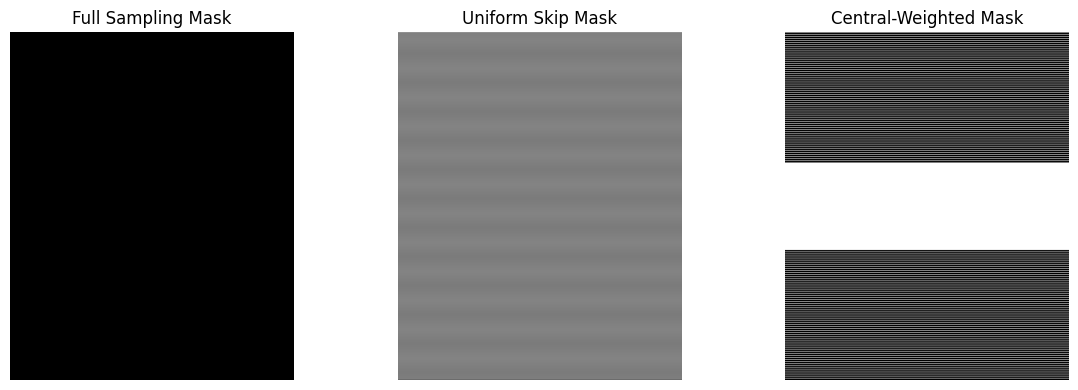

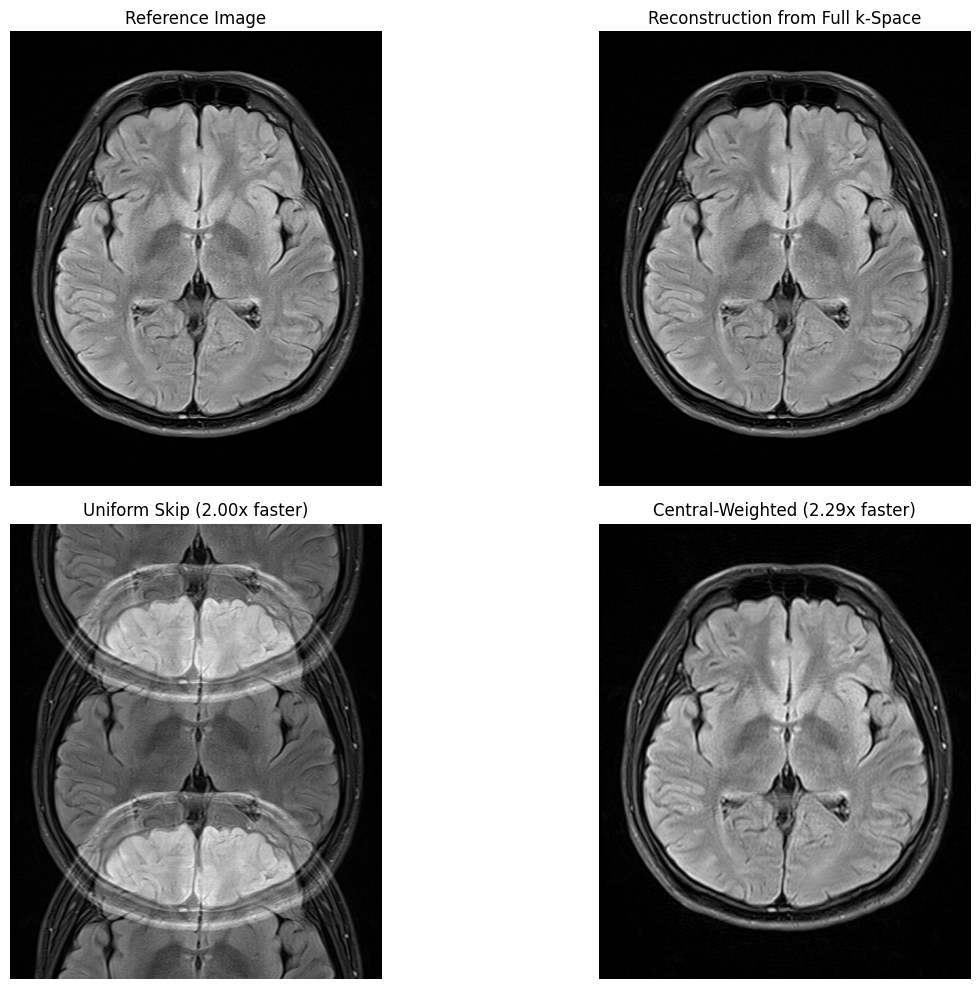

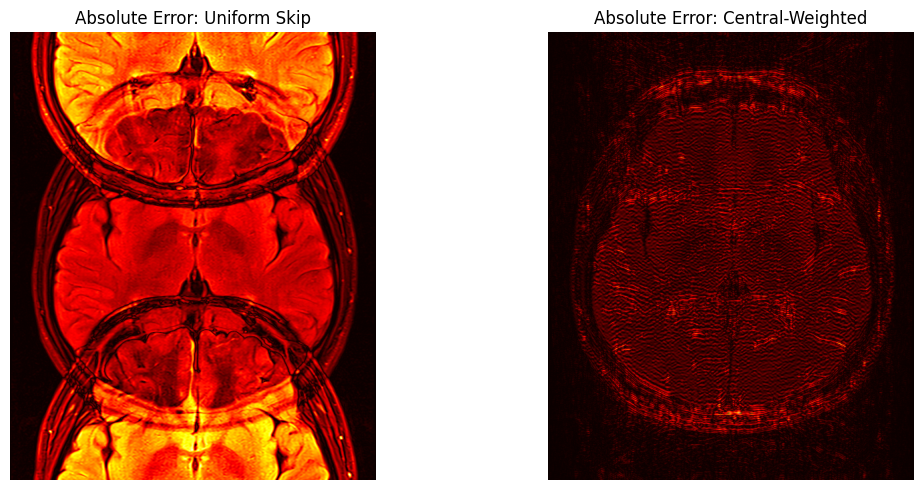


Interpretation:
1. Uniform skipping gives higher speed by removing phase-encode lines regularly,
   but it tends to produce stronger aliasing/wrap-around artifacts because the
   sampling pattern is periodic and sparse across ky.
2. Central-weighted retention preserves more low-frequency information, so overall
   contrast and anatomy remain better even though some fine detail is lost.
3. For anatomy-focused brain imaging, the central-weighted strategy is usually the
   better speed-vs-quality compromise because it protects gross tissue contrast while
   still reducing acquisition burden.

Recommended strategy:
Use the central-weighted undersampling pattern for a moderate-speed acquisition,
because it better preserves clinically relevant anatomy and contrast than uniform skipping.


In [17]:
print("=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===")

# TODO 1: Define protocol settings and estimate scan time.
n_pe_full = reference_image.shape[0]
def estimate_scan_time(tr_ms, n_pe, nex=1, etl=1):
    return (tr_ms / 1000.0) * (n_pe / etl) * nex

protocols = {
    "Full sampling, ETL=1, NEX=1": {"TR": 2500, "N_PE": n_pe_full, "NEX": 1, "ETL": 1 },
    "Full sampling, ETL=1, NEX=2": {"TR": 2500, "N_PE": n_pe_full, "NEX": 2, "ETL": 1 },
    "Faster ETL=2": { "TR": 2500, "N_PE": n_pe_full, "NEX": 1, "ETL": 2},
    "Reduced phase encodes": {"TR": 2500, "N_PE": int(0.7 * n_pe_full), "NEX": 1, "ETL": 1},
}
print("\nEstimated Scan Times:")
for name, p in protocols.items():
    scan_time_s = estimate_scan_time(p["TR"], p["N_PE"], p["NEX"], p["ETL"])
    print(f"{name}: {scan_time_s:.1f} s ({scan_time_s/60:.2f} min)")

# TODO 2: Compute k-space from the reference image.
kspace = np.fft.fft2(reference_image)
kspace_shifted = np.fft.fftshift(kspace)

rows, cols = reference_image.shape
crow = rows // 2

# TODO 3: Create at least two undersampling masks.
uniform_mask = np.zeros((rows, cols), dtype=np.float32)
uniform_mask[::2, :] = 1.0

central_weighted_mask = np.zeros((rows, cols), dtype=np.float32)
center_fraction = 0.25
half_band = int((rows * center_fraction) / 2)

central_weighted_mask[crow - half_band:crow + half_band, :] = 1.0

for r in range(rows):
    if r < crow - half_band or r >= crow + half_band:
        if r % 4 == 0:
            central_weighted_mask[r, :] = 1.0 

full_mask = np.ones((rows, cols), dtype=np.float32)

# TODO 4: Reconstruct images for each mask.
def reconstruct_from_kspace(kspace_shifted):
    recon = np.fft.ifft2(np.fft.ifftshift(kspace_shifted))
    return normalize_image(np.abs(recon))

kspace_full = kspace_shifted * full_mask
kspace_uniform = kspace_shifted * uniform_mask
kspace_central = kspace_shifted * central_weighted_mask

recon_full = reconstruct_from_kspace(kspace_full)
recon_uniform = reconstruct_from_kspace(kspace_uniform)
recon_central = reconstruct_from_kspace(kspace_central)

# TODO 5: Compare image quality and speed.
def nrmse(reference, test):
    return np.sqrt(np.mean((reference - test) ** 2)) / (np.sqrt(np.mean(reference ** 2)) + 1e-12)

uniform_retention = np.mean(uniform_mask)
central_retention = np.mean(central_weighted_mask)

uniform_accel = 1.0 / uniform_retention
central_accel = 1.0 / central_retention

uniform_error = nrmse(reference_image, recon_uniform)
central_error = nrmse(reference_image, recon_central)

print("\nUndersampling Summary:")
print(f"Uniform Mask: retained {100*uniform_retention:.1f}% of k-space lines, "
      f"acceleration ~{uniform_accel:.2f}x, NRMSE = {uniform_error:.4f}")
print(f"Central-Weighted Mask: retained {100*central_retention:.1f}% of k-space lines, "
      f"acceleration ~{central_accel:.2f}x, NRMSE = {central_error:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(full_mask, cmap="gray")
plt.title("Full Sampling Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(uniform_mask, cmap="gray")
plt.title("Uniform Skip Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(central_weighted_mask, cmap="gray")
plt.title("Central-Weighted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(reference_image, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(recon_full, cmap="gray")
plt.title("Reconstruction from Full k-Space")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(recon_uniform, cmap="gray")
plt.title(f"Uniform Skip ({uniform_accel:.2f}x faster)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(recon_central, cmap="gray")
plt.title(f"Central-Weighted ({central_accel:.2f}x faster)")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.abs(reference_image - recon_uniform), cmap="hot")
plt.title("Absolute Error: Uniform Skip")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.abs(reference_image - recon_central), cmap="hot")
plt.title("Absolute Error: Central-Weighted")
plt.axis("off")

plt.tight_layout()
plt.show()
# TODO 6: Recommend one acquisition strategy.
print("\nInterpretation:")
print("1. Uniform skipping gives higher speed by removing phase-encode lines regularly,")
print("   but it tends to produce stronger aliasing/wrap-around artifacts because the")
print("   sampling pattern is periodic and sparse across ky.")
print("2. Central-weighted retention preserves more low-frequency information, so overall")
print("   contrast and anatomy remain better even though some fine detail is lost.")
print("3. For anatomy-focused brain imaging, the central-weighted strategy is usually the")
print("   better speed-vs-quality compromise because it protects gross tissue contrast while")
print("   still reducing acquisition burden.")

if central_error < uniform_error:
    print("\nRecommended strategy:")
    print("Use the central-weighted undersampling pattern for a moderate-speed acquisition,")
    print("because it better preserves clinically relevant anatomy and contrast than uniform skipping.")
else:
    print("\nRecommended strategy:")
    print("Use the uniform skipping pattern only if maximum speed is the priority and some")
    print("aliasing/artifact can be tolerated.")

---

# Part 3: Pulse Sequences and Image Weighting Strategies

## Key Concepts

**Gradient Echo (GRE):**
- Uses gradient reversal (no 180° RF pulse)
- Fast imaging, short TR/TE possible
- T2* sensitive (susceptibility effects prominent)

**Spin Echo (SE):**
- Uses 90° + 180° refocusing pulse
- Refocuses static inhomogeneity dephasing
- Produces true T2 contrast

**Fast Spin Echo (FSE/TSE):**
- Multiple echoes per TR (echo train length, ETL)
- Greatly reduces scan time
- Long ETL may introduce T2 blurring

**Inversion Recovery (STIR/FLAIR):**
- Inversion pulse + TI to null specific tissue
- STIR suppresses short-T1 tissues (fat)
- FLAIR suppresses CSF for brain lesion conspicuity

## 3.1 Sequence Selection and Parameter Trade-offs

### **Questions 9**
You need to image a lesion near the paranasal sinuses, where susceptibility effects are strong.

- a) Would GRE or SE better preserve lesion signal? Explain using susceptibility and $T_2^*$ ideas.
- b) If signal dropout is still a problem, would you shorten TE or change sequence family first? Defend your answer.
- c) Why can GRE still be the right choice for some fast 3D exams even in susceptibility-prone regions?

### **Questions 10**
An FSE sequence uses $TR=4000$ ms, $N_{PE}=256$, and $NEX=1$.

- a) Compute scan time for standard SE ($ETL = 1$), FSE with $ETL = 8$, and FSE with $ETL = 16$.
- b) Why does long ETL reduce image sharpness?
- c) For a routine T2-weighted brain exam, what ETL range would you choose, and why?


## 3.2 Sequence Timing and Contrast Simulator

### **Coding Exercise 5**
Build a simplified MRI sequence simulator to compare contrast behavior across GRE, SE, and IR-style timing.

Tasks:
1. Define representative tissue parameters ($T_1$, $T_2$, $T_2^*$).
2. Implement simplified signal models:
   - GRE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2^*}$
   - SE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2}$
   - IR (long TR approximation): $M_z(TI)=M_0(1-2e^{-TI/T_1})$
3. Sweep TE and TR, and visualize signal trends.
4. Demonstrate tissue nulling with TI (e.g., STIR-like fat suppression, FLAIR-like CSF suppression).
5. Interpret which parameter combinations best match each intended weighting.

**Helpful Note:** Review **Lecture 27** notes on GRE/SE and inversion recovery (STIR/FLAIR). You can also use the scan-time discussion in **Question 10** and the null-TI idea in **Question 11** to guide your interpretation.

=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===


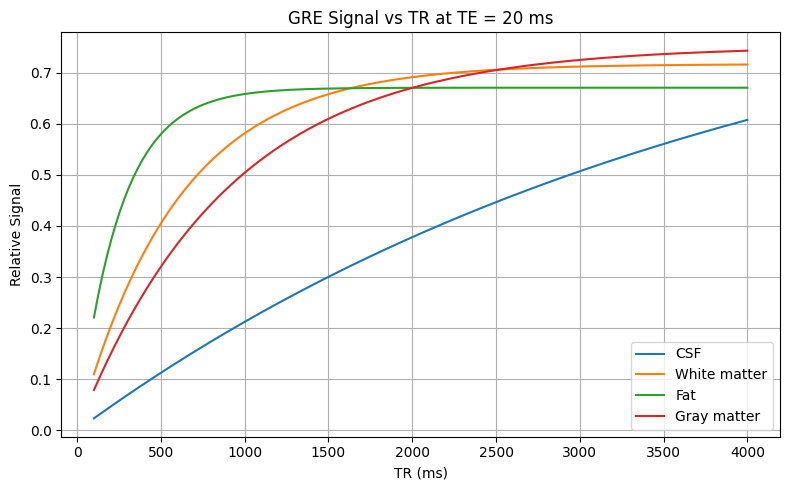

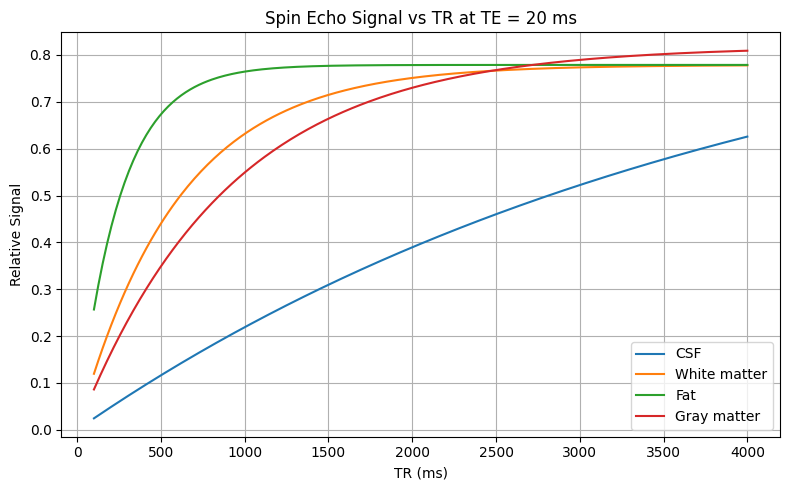

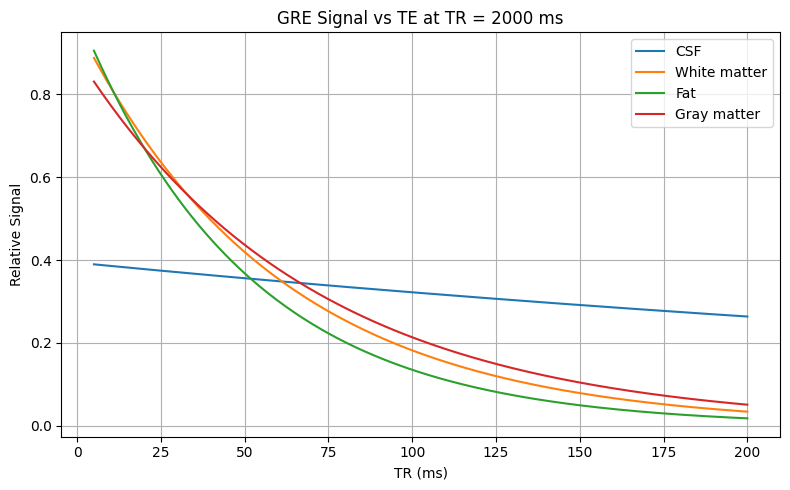

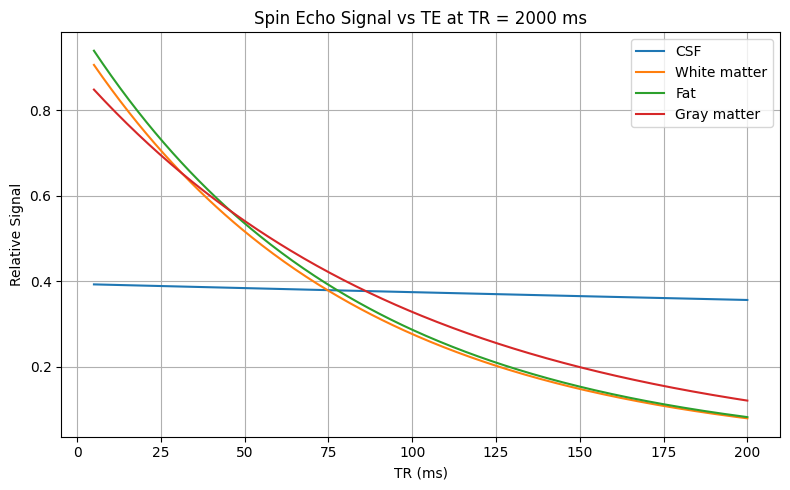

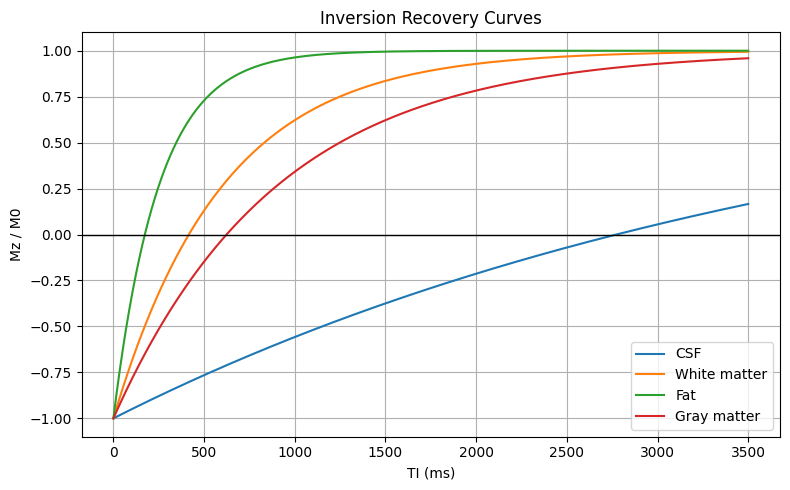

Estimated STIR-like fat null TI: 173.3 ms
Estimated FLAIR-like CSF null TI: 2772.6 ms


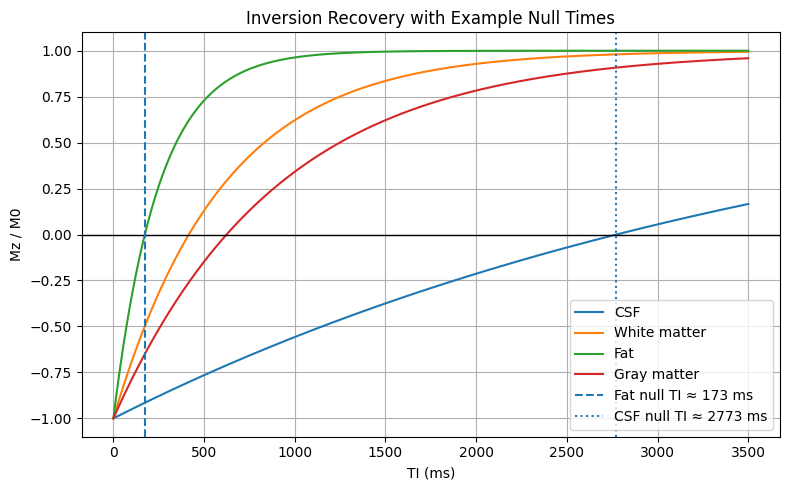


Example protocol signal snapshots:

GRE T1-like (TR=400 ms, TE=10 ms)
  CSF: 0.0933
  White matter: 0.4119
  Fat: 0.6534
  Gray matter: 0.3111

SE T2-like (TR=3000 ms, TE=100 ms)
  CSF: 0.5019
  White matter: 0.2846
  Fat: 0.2865
  Gray matter: 0.3548

SE PD-like (TR=3000 ms, TE=15 ms)
  CSF: 0.5237
  White matter: 0.8234
  Fat: 0.8290
  Gray matter: 0.8300


In [19]:
print("=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0


def gre_signal(tr_ms, te_ms, t1_ms, t2star_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2star_ms)


def se_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


# TODO 1: Define tissue parameters.
tissues = {
    "CSF": {"T1": 4000, "T2": 2000, "T2*": 500},
    "White matter": {"T1": 600, "T2": 80, "T2*": 60},
    "Fat": {"T1": 250, "T2": 80, "T2*": 50},
    "Gray matter": {"T1": 900, "T2": 100, "T2*": 70},
}

# TODO 2: Create TR, TE, and TI sweeps.
tr_sweep = np.linspace(100, 4000, 300)
te_sweep = np.linspace(5, 200, 300)
ti_sweep = np.linspace(0, 3500, 400)

fixed_te = 20
fixed_tr = 2000

# TODO 3: Compute GRE and SE signal trends.
gre_v_tr = {}
se_v_tr = {}
gre_v_te = {}
se_v_te = {}

for tissue, props in tissues.items():
    gre_v_tr[tissue] = gre_signal(tr_sweep, fixed_te, props["T1"], props["T2*"])
    se_v_tr[tissue] = se_signal(tr_sweep, fixed_te, props["T1"], props["T2"])
    gre_v_te[tissue] = gre_signal(fixed_tr, te_sweep, props["T1"], props["T2*"])
    se_v_te[tissue] = se_signal(fixed_tr, te_sweep, props["T1"], props["T2"])

# TODO 4: Plot GRE and SE signal behavior.
plt.figure(figsize=(8,5))
for tissue in tissues:
    plt.plot(tr_sweep, gre_v_tr[tissue], label=tissue)
plt.xlabel("TR (ms)")
plt.ylabel("Relative Signal")
plt.title(f"GRE Signal vs TR at TE = {fixed_te} ms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
for tissue in tissues:
    plt.plot(tr_sweep, se_v_tr[tissue], label=tissue)
plt.xlabel("TR (ms)")
plt.ylabel("Relative Signal")
plt.title(f"Spin Echo Signal vs TR at TE = {fixed_te} ms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
for tissue in tissues:
    plt.plot(te_sweep, gre_v_te[tissue], label=tissue)
plt.xlabel("TR (ms)")
plt.ylabel("Relative Signal")
plt.title(f"GRE Signal vs TE at TR = {fixed_tr} ms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
for tissue in tissues:
    plt.plot(te_sweep, se_v_te[tissue], label=tissue)
plt.xlabel("TR (ms)")
plt.ylabel("Relative Signal")
plt.title(f"Spin Echo Signal vs TE at TR = {fixed_tr} ms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# TODO 5: Compute inversion-recovery curves across TI.
ir_curves = {}
for tissue, props in tissues.items():
    ir_curves[tissue] = ir_mz(ti_sweep, props["T1"], M0)

plt.figure(figsize=(8, 5))
for tissue in tissues:
    plt.plot(ti_sweep, ir_curves[tissue], label=tissue)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("TI (ms)")
plt.ylabel("Mz / M0")
plt.title("Inversion Recovery Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# TODO 6: Estimate STIR-like and FLAIR-like null times.
stir_like_ti = null_ti(tissues["Fat"]["T1"])
flair_like_ti = null_ti(tissues["CSF"]["T1"])

print(f"Estimated STIR-like fat null TI: {stir_like_ti:.1f} ms")
print(f"Estimated FLAIR-like CSF null TI: {flair_like_ti:.1f} ms")

plt.figure(figsize=(8, 5))
for tissue in tissues:
    plt.plot(ti_sweep, ir_curves[tissue], label=tissue)

plt.axhline(0, color="black", linewidth=1)
plt.axvline(stir_like_ti, linestyle="--", label=f"Fat null TI ≈ {stir_like_ti:.0f} ms")
plt.axvline(flair_like_ti, linestyle=":", label=f"CSF null TI ≈ {flair_like_ti:.0f} ms")

plt.xlabel("TI (ms)")
plt.ylabel("Mz / M0")
plt.title("Inversion Recovery with Example Null Times")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

example_protocols = {
    "GRE T1-like": {"type": "GRE", "TR": 400, "TE": 10},
    "SE T2-like": {"type": "SE", "TR": 3000, "TE": 100},
    "SE PD-like": {"type": "SE", "TR": 3000, "TE": 15},
}

print("\nExample protocol signal snapshots:")
for name, p in example_protocols.items():
    print(f"\n{name} (TR={p['TR']} ms, TE={p['TE']} ms)")
    for tissue, props in tissues.items():
        if p["type"] == "GRE":
            sig = gre_signal(p["TR"], p["TE"], props["T1"], props["T2*"])
        else:
            sig = se_signal(p["TR"], p["TE"], props["T1"], props["T2"])
        print(f"  {tissue}: {sig:.4f}")
# TODO 7: Add a short interpretation of the contrast behavior.

# ...

## 3.3 Inversion Recovery Case Analysis

### **Questions 11**
You are selecting between STIR and FLAIR for two clinical applications.

- a) For edema near fat and for periventricular brain lesions, which sequence would you choose in each case, and why?
- b) Using $TI_{null} \approx T_1\ln 2$, estimate the null TI for fat with $T_1 = 250$ ms and for CSF with $T_1 = 4000$ ms.
- c) Why is STIR generally avoided after gadolinium enhancement?

### **Questions 12**
A protocol engineer proposes replacing all SE scans with GRE to reduce scan time.

- a) Give three clinical situations where this would be a poor choice.
- b) Propose a mixed GRE and SE/FSE protocol strategy, and justify it.
- c) Name one hardware or safety issue that also argues against relying on only one sequence family.


## 3.4 Inversion Recovery and Echo-Train Trade-off Simulation

### **Coding Exercise 6**
Implement a simulation that links inversion recovery behavior with FSE timing trade-offs.

Tasks:
1. Compute $M_z(TI)=M_0(1-2e^{-TI/T_1})$ for fat-like and CSF-like tissues.
2. Estimate TI values that null each tissue class.
3. Simulate scan-time changes for ETL = 1, 8, 16, 24 using fixed TR and $N_{PE}$.
4. Build a short decision table: when to prioritize STIR/FLAIR contrast vs faster FSE acquisition.

**Helpful Note:** You can use **Question 11** values directly for fat and CSF. Review **Lecture 27** notes on inversion recovery and FSE/ETL trade-offs.

=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===


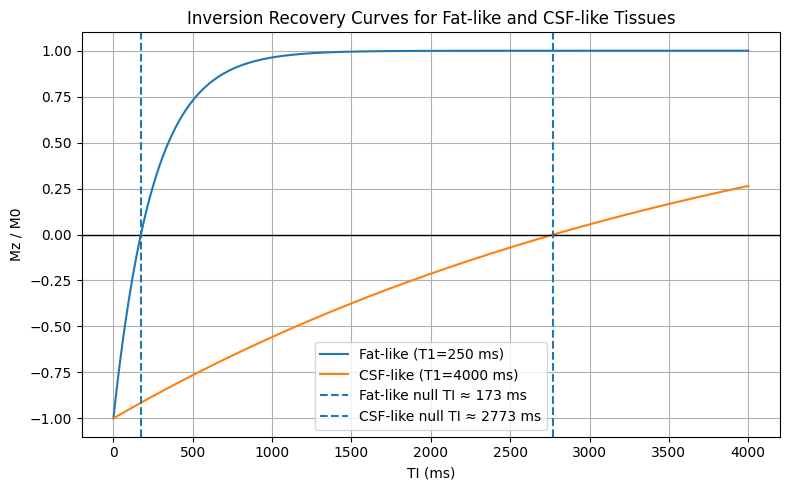


Estimated Null TI Valuees:
    Fat-like: TI_null ≈ 173.3 ms
    CSF-like: TI_null ≈ 2772.6 ms

Estimated scan times:
  ETL = 1: 480.0 s (8.00 min)
  ETL = 8: 60.0 s (1.00 min)
  ETL = 16: 30.0 s (0.50 min)
  ETL = 24: 20.0 s (0.33 min)

Decision table:
- Priority: Suppress fat signal
  Recommended approach: STIR-like inversion recovery
  Reason: Choose TI near the fat null point to suppress short-T1 fat signal.
- Priority: Suppress CSF signal
  Recommended approach: FLAIR-like inversion recovery
  Reason: Choose TI near the CSF null point to suppress long-T1 fluid signal.
- Priority: Reduce scan time substantially
  Recommended approach: Use longer ETL in FSE
  Reason: Longer ETL fills more k-space lines per TR and reduces acquisition time.
- Priority: Preserve cleaner contrast/sharper control of echo timing
  Recommended approach: Use shorter ETL
  Reason: Shorter ETL reduces blurring and contrast averaging across the echo train.


In [20]:
print("=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===")

import numpy as np

M0 = 1.0

def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


def estimate_scan_time_seconds(tr_ms, n_pe, nex, etl):
    etl = max(1, int(etl))
    return (tr_ms / 1000.0) * (n_pe / etl) * nex


# TODO 1: Define T1 values for fat-like and CSF-like tissues.
tissues = {
    "Fat-like": {"T1": 250},
    "CSF-like": {"T1": 4000},
}

# TODO 2: Create a TI sweep.
ti_sweep = np.linspace(0, 4000, 500)

# TODO 3: Compute Mz(TI) and identify the null point for each tissue.
ir_curves = {}
null_times = {}

for tissue, props in tissues.items():
    t1 = props["T1"]
    ir_curves[tissue] = ir_mz(ti_sweep, t1, M0)
    null_times[tissue] = null_ti(t1)

# Plot inversion recovery curves
plt.figure(figsize=(8, 5))
for tissue in tissues:
    plt.plot(ti_sweep, ir_curves[tissue], label=f"{tissue} (T1={tissues[tissue]['T1']} ms)")

plt.axhline(0, color="black", linewidth=1)

for tissue, ti_null in null_times.items():
    plt.axvline(ti_null, linestyle="--", label=f"{tissue} null TI ≈ {ti_null:.0f} ms")

plt.xlabel("TI (ms)")
plt.ylabel("Mz / M0")
plt.title("Inversion Recovery Curves for Fat-like and CSF-like Tissues")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# TODO 4: Summarize the null TI values.
print("\nEstimated Null TI Valuees:")
for tissue, ti_null in null_times.items():
    print(f"    {tissue}: TI_null ≈ {ti_null:.1f} ms")

# TODO 5: Compute scan times for ETL = 1, 8, 16, 24.
tr_ms = 2500
n_pe = 192
nex = 1
etl_values = [1, 8, 16, 24]

scan_times = {}
for etl in etl_values:
    scan_times[etl] = estimate_scan_time_seconds(tr_ms, n_pe, nex, etl)

print("\nEstimated scan times:")
for etl, time_s in scan_times.items():
    print(f"  ETL = {etl}: {time_s:.1f} s ({time_s/60:.2f} min)")

# TODO 6: Build a short comparison table or list.
decision_table = [
    {
        "Priority": "Suppress fat signal",
        "Recommended approach": "STIR-like inversion recovery",
        "Reason": "Choose TI near the fat null point to suppress short-T1 fat signal."
    },
    {
        "Priority": "Suppress CSF signal",
        "Recommended approach": "FLAIR-like inversion recovery",
        "Reason": "Choose TI near the CSF null point to suppress long-T1 fluid signal."
    },
    {
        "Priority": "Reduce scan time substantially",
        "Recommended approach": "Use longer ETL in FSE",
        "Reason": "Longer ETL fills more k-space lines per TR and reduces acquisition time."
    },
    {
        "Priority": "Preserve cleaner contrast/sharper control of echo timing",
        "Recommended approach": "Use shorter ETL",
        "Reason": "Shorter ETL reduces blurring and contrast averaging across the echo train."
    },
]

print("\nDecision table:")
for row in decision_table:
    print(f"- Priority: {row['Priority']}")
    print(f"  Recommended approach: {row['Recommended approach']}")
    print(f"  Reason: {row['Reason']}")

# TODO 7: Add a short decision summary.

# ...

---

# Part 4: Advanced MRI, Artifacts, and Safety

## Key Concepts

**Diffusion-Weighted Imaging (DWI):**
- Sensitive to Brownian motion of water
- Signal model: $S=S_0e^{-bD}$
- Restricted diffusion appears bright on DWI and dark on ADC maps

**Echo Planar Imaging (EPI):**
- Very fast acquisition (often one excitation)
- Enables DWI/fMRI but is prone to distortion and ghosting

**Common Artifacts:**
- Motion ghosting (phase-encode direction)
- Aliasing/wrap-around (insufficient FOV)
- Chemical shift (fat-water frequency mismatch)
- Susceptibility distortion/signal loss (metal, air interfaces)
- Gibbs/truncation ringing (finite k-space sampling)

**MRI Safety Domains:**
- Static field hazards (projectiles, implants)
- RF heating and SAR limits
- Gradient hazards (PNS, acoustic noise)
- Strict screening and zone control are essential

## 4.1 Diffusion and EPI Interpretation

### **Questions 13**
A patient with acute neurologic deficit has:
- DWI: focal bright signal in right MCA territory
- ADC map: corresponding dark region

- a) Interpret this finding physiologically, and explain why DWI can detect acute ischemia earlier than CT.
- b) What is T2 shine-through, and how does the ADC map help distinguish it from true restricted diffusion?
- c) Why is EPI commonly used for DWI even though it is sensitive to distortion?

### **Questions 14**
Given $S=S_0e^{-bD}$, compare expected diffusion signal for:
- Tissue X: $D=0.4\times10^{-3}\ \mathrm{mm^2/s}$
- Tissue Y: $D=1.0\times10^{-3}\ \mathrm{mm^2/s}$
for $b=1000\ \mathrm{s/mm^2}$.

- a) Compute normalized signals $S/S_0$ for both tissues.
- b) Which tissue appears brighter on high-b DWI, and why?
- c) What is gained and what is lost when b-value is increased?
- d) Why are at least two b-values needed for ADC, and why are more than two often useful?


## 4.2 DICOM Slice Navigation and Display-Window Analysis

### **Coding Exercise 7**
Use the DICOM slice viewer to study how display settings affect what anatomy is visible. The DICOM folder contains **6 series from a right knee MRI exam**. Use the table below to orient yourself before choosing a series:

| Series | Weighting | Plane |
|--------|-----------|-------|
| `series-000001` | Proton density | Axial |
| `series-000002` | Proton density | Coronal |
| `series-000003` | T1-weighted | Coronal |
| `series-000004` | Localizer only | Multi |
| `series-000005` | PD + fat suppression | Sagittal |
| `series-000006` | T2-weighted | Sagittal |

**Note:** `series-000004` is a quick scout/localizer used for planning — it has very low contrast and is not useful for this exercise. Choose any of the other five series.

**PART A: Choose your data**
1. Pick **one series** from the dropdown.
2. Select **3 slice indices** from that series, spread across the stack (early, middle, late).
3. Record your 3 chosen slice numbers.

**PART B: Compare display settings**
For each of the 3 slices, evaluate all three settings below:
1. **Baseline:** Low % = 2, High % = 98
2. **Higher contrast:** Low % = 10, High % = 90
3. **Wider range:** Low % = 1, High % = 99

**PART C: Required output figure**
1. Create one figure arranged as **3 rows × 3 columns**:
   - Rows = your 3 selected slice indices
   - Columns = the 3 display settings above
2. Add clear titles/labels with slice index and (% low, % high).

**PART D: Short analysis**
1. For each slice, choose the setting that best shows anatomy boundaries.
2. Briefly state what became easier/harder to see as you changed % settings.
3. Explain in 3-5 sentences why changing Low%/High% changes visibility even though underlying pixel data is unchanged.

In [ ]:
# Run this cell to load the slice viewer for the next coding exercises.
%pip install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg
%pip install --upgrade pip
from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc


def find_dicom_root() -> Path:
    # Update this path to point to your own "DICOMS" folder location.
    # Example: Path("/Users/yourname/Desktop/DICOMS")

    dicom_path = Path("/Users/juliana/Desktop/DICOMS") # Update this if needed

    if dicom_path.exists() and dicom_path.is_dir():
        return dicom_path

    raise FileNotFoundError(
        "Could not find the DICOMS folder. Please update the path to your local DICOMS directory."
    )

def dicom_sort_key(ds, path: Path):
    instance_number = getattr(ds, "InstanceNumber", None)
    if instance_number is not None:
        try:
            return (0, int(instance_number))
        except Exception:
            pass

    position = getattr(ds, "ImagePositionPatient", None)
    if position is not None:
        try:
            return (1, float(position[-1]))
        except Exception:
            pass

    return (2, path.name)


def load_series(series_dir: Path):
    dicom_paths = sorted(series_dir.glob("*.dcm"))
    if not dicom_paths:
        raise ValueError(f"No DICOM files found in {series_dir}")

    slice_records = []
    for dicom_path in dicom_paths:
        ds = pydicom.dcmread(dicom_path)
        pixel_array = ds.pixel_array.astype(np.float32)
        slice_records.append((dicom_sort_key(ds, dicom_path), pixel_array))

    slice_records.sort(key=lambda item: item[0])
    return np.stack([record[1] for record in slice_records], axis=0)


def window_image(image: np.ndarray, low_pct: int = 2, high_pct: int = 98):
    low_pct = max(0, min(99, low_pct))
    high_pct = max(low_pct + 1, min(100, high_pct))

    lo, hi = np.percentile(image, (low_pct, high_pct))
    if np.isclose(lo, hi):
        lo = float(np.min(image))
        hi = float(np.max(image))
        if np.isclose(lo, hi):
            hi = lo + 1.0

    return np.clip(image, lo, hi), float(lo), float(hi)


def create_slice_viewer(series_data: dict):
    series_names = sorted(series_data.keys())
    default_series = series_names[0]
    default_volume = series_data[default_series]

    series_dropdown = widgets.Dropdown(
        options=series_names,
        value=default_series,
        description="Series",
        layout=widgets.Layout(width="300px"),
    )
    slice_slider = widgets.IntSlider(
        min=0,
        max=default_volume.shape[0] - 1,
        step=1,
        value=default_volume.shape[0] // 2,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )
    low_slider = widgets.IntSlider(
        min=0,
        max=30,
        step=1,
        value=2,
        description="Low %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )
    high_slider = widgets.IntSlider(
        min=70,
        max=100,
        step=1,
        value=98,
        description="High %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )

    def on_series_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        volume = series_data[change["new"]]
        slice_slider.max = volume.shape[0] - 1
        slice_slider.value = volume.shape[0] // 2

    series_dropdown.observe(on_series_change, names="value")

    def render(series_name, slice_idx, low_pct, high_pct):
        volume = series_data[series_name]
        image = volume[slice_idx]
        image_disp, lo, hi = window_image(image, low_pct, high_pct)

        plt.figure(figsize=(6, 6))
        plt.imshow(image_disp, cmap="gray", vmin=lo, vmax=hi)
        plt.title(f"{series_name} | slice {slice_idx}/{volume.shape[0] - 1}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    controls = {
        "series_name": series_dropdown,
        "slice_idx": slice_slider,
        "low_pct": low_slider,
        "high_pct": high_slider,
    }

    viewer_output = widgets.interactive_output(render, controls)
    ui = widgets.VBox([
        widgets.HTML("<b>Interactive DICOM Slice Viewer</b>"),
        widgets.HBox([series_dropdown, slice_slider]),
        widgets.HBox([low_slider, high_slider]),
        viewer_output,
    ])
    display(ui)


# Load DICOM series and launch the slice viewer
dicom_root = find_dicom_root()
series_dirs = sorted([path for path in dicom_root.iterdir() if path.is_dir() and path.name.startswith("series-")])

if not series_dirs:
    raise ValueError(f"No series-* folders found under {dicom_root}")

series_data = {series_dir.name: load_series(series_dir) for series_dir in series_dirs}

create_slice_viewer(series_data)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


=== Coding Exercise 7: Windowing Comparison Figure ===
Chosen Series: series-000004
Chosen Slice Indicies: [8, 13, 21]


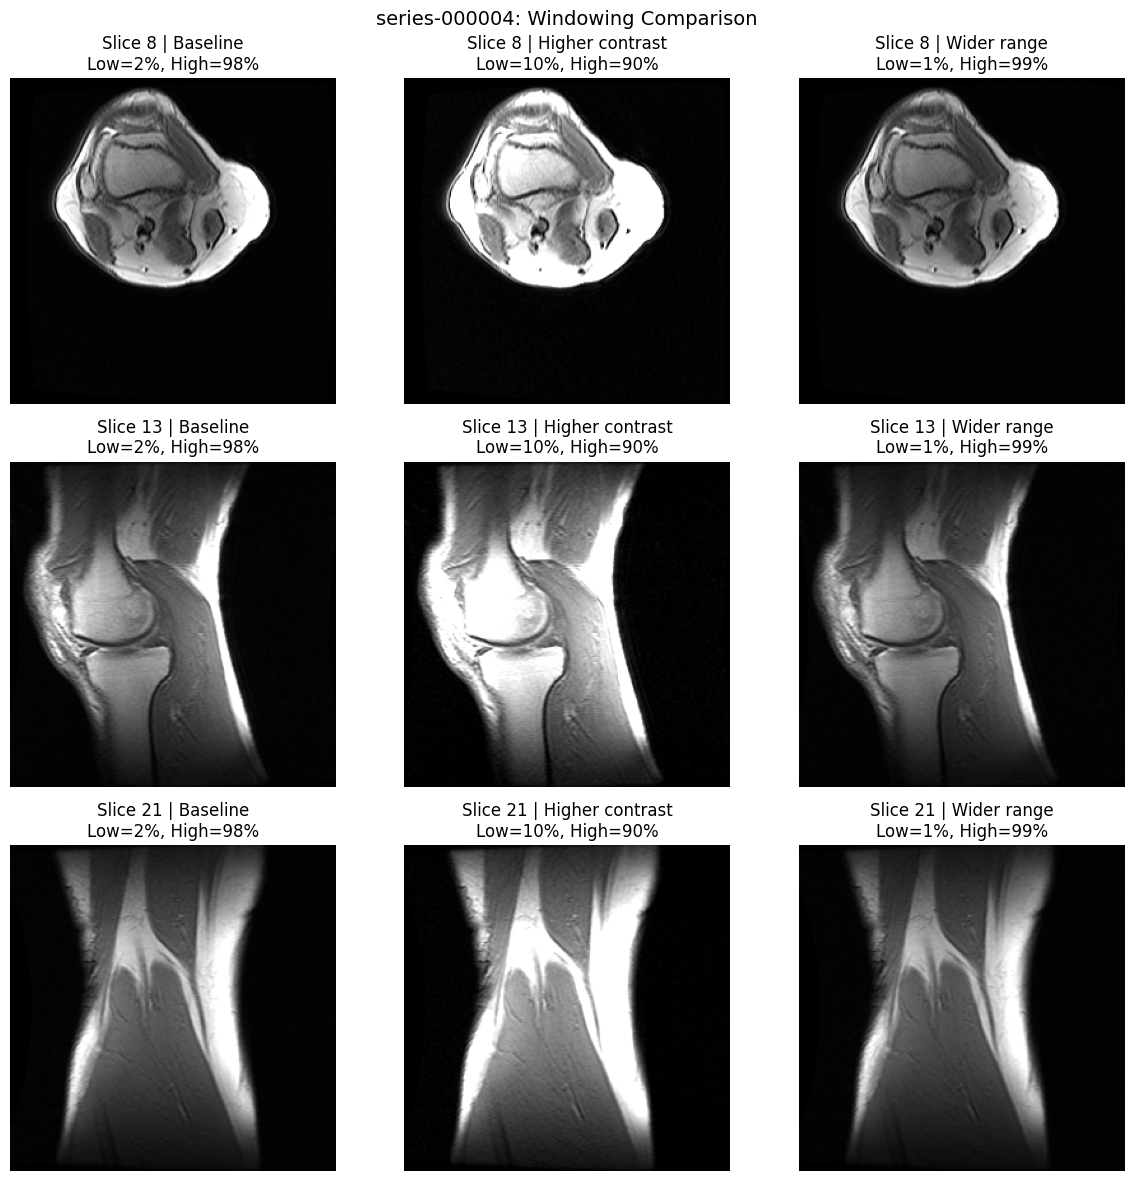

In [2]:
print("=== Coding Exercise 7: Windowing Comparison Figure ===")

# TODO 1: Choose one series and three slice indices.
chosen_series = "series-000004"   
volume = series_data[chosen_series]

num_slices = volume.shape[0]
chosen_slices = [8, 13, 21]

print(f"Chosen Series: {chosen_series}")
print(f"Chosen Slice Indicies: {chosen_slices}")

# TODO 2: Define the three display settings.
display_settings = [
    ("Baseline", 2, 98),
    ("Higher contrast", 10, 90),
    ("Wider range", 1, 99),
]

# TODO 3: Build the 3 x 3 comparison figure.
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, slice_idx in enumerate(chosen_slices):
    image = volume[slice_idx]

    for col, (label, low_pct, high_pct) in enumerate(display_settings):
        image_disp, lo, hi = window_image(image, low_pct, high_pct)

        ax = axes[row, col]
        ax.imshow(image_disp, cmap="gray", vmin=lo, vmax=hi)
        ax.set_title(f"Slice {slice_idx} | {label}\nLow={low_pct}%, High={high_pct}%")
        ax.axis("off")

plt.suptitle(f"{chosen_series}: Windowing Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# TODO 4: Add a short analysis of which setting best shows anatomy boundaries.
# ...

## 4.3 MRI Safety Scenario Analysis

### **Questions 15**
A patient arrives for MRI with uncertain implant documentation.

- a) Outline a safe decision pathway before scanning.
- b) Distinguish MR Safe, MR Conditional, and MR Unsafe, and explain why “the scanner is off” is not a valid safety assumption.
- c) If a medical emergency occurs in Zone IV, what should happen first and why?

### **Questions 16**
You are optimizing a high-field MRI protocol and observe elevated SAR estimates.

- a) List sequence choices that tend to increase SAR.
- b) Suggest practical protocol changes that reduce SAR while keeping the exam diagnostic.
- c) How are RF heating hazards different from gradient-related acoustic noise or PNS?
- d) Why are patient screening and in-scan monitoring still necessary even after protocol optimization?


## 4.4 Design Component: MRI Acquisition + Reconstruction

### **Coding Exercise 8**
In this design task, you will act like an MRI protocol designer for **one** clinical problem. Your goal is to choose a reasonable scan approach, show how the data would be acquired and reconstructed, and explain why your final design is a good choice.

### **Choose ONE scenario**
1. **Acute ischemic stroke detection**: focus on diffusion sensitivity and speed.
2. **Brain lesion near sinuses**: focus on reducing susceptibility-related signal loss and distortion.
3. **Musculoskeletal edema near fat**: focus on fluid sensitivity and fat suppression.

### **Part A — Protocol Definition**
Define the MRI protocol you would use.
1. Choose a sequence family and briefly explain why it fits the scenario.
2. Specify reasonable imaging parameters: TR, TE, TI (if used), flip angle, matrix, FOV, N_PE, NEX, ETL.
3. Estimate scan time and describe the expected image weighting or contrast.

### **Part B — Acquisition Strategy**
Explain how the data will be collected in k-space.
1. Choose a strategy such as full Cartesian, partial Fourier, accelerated undersampling, or a non-Cartesian option.
2. Explain what you expect to gain in speed.
3. Explain what artifact or image-quality risk this choice introduces.

### **Part C — Reconstruction and Comparison**
Show two versions of the reconstruction.
1. Create one **baseline reconstruction** using your standard approach.
2. Create one **alternative reconstruction** that is either faster or more robust.
3. Compare the two using at least one quantitative measure and a short qualitative comment.
4. State which version you would actually choose for this scenario.

### **Part D — Safety + Final Recommendation**
Finish with a clinically reasonable recommendation.
1. List safety issues that matter for your scenario (for example: SAR, implant screening, static-field concerns, acoustic noise, or PNS).
2. Give a final recommendation that clearly states:
   - which protocol you would use
   - why it fits the clinical problem
   - what trade-off you are accepting

 **Helpful Note:** You may reuse a reference image from earlier coding exercises, or use your own/synthetic image and state assumptions.

In [10]:
print("=== Coding Exercise 8: MRI Design Component ===")

import matplotlib.pyplot as plt
import numpy as np


def estimate_scan_time_seconds(protocol):
    etl = max(1, int(protocol.get("ETL", 1) or 1))
    return (protocol["TR_ms"] / 1000.0) * (protocol["N_PE"] / etl) * protocol["NEX"]


def get_reference_image():
    if "reference_image" in globals():
        return reference_image
    if "image" in globals():
        return image

    rows, cols = 256, 256
    rr, cc = np.ogrid[:rows, :cols]
    phantom = np.zeros((rows, cols), dtype=np.float32)
    body_mask = ((rr - rows / 2) ** 2) / (70 ** 2) + ((cc - cols / 2) ** 2) / (95 ** 2) <= 1
    lesion_mask = ((rr - rows / 2 + 18) ** 2) / (16 ** 2) + ((cc - cols / 2 - 10) ** 2) / (20 ** 2) <= 1
    phantom[body_mask] = 0.75
    phantom[lesion_mask] = 1.0
    return phantom


def reconstruct_from_mask(image_2d, mask):
    kspace = np.fft.fftshift(np.fft.fft2(image_2d))
    reconstructed = np.fft.ifft2(np.fft.ifftshift(kspace * mask))
    return np.abs(reconstructed), kspace


def rmse(reference, test):
    return float(np.sqrt(np.mean((reference - test) ** 2)))


reference = get_reference_image()

# =====================
# PART A — Protocol Definition
# =====================
# TODO 1: Pick a scenario and define one clinically reasonable protocol.
# TODO 2: Print the protocol in a clean summary table or formatted block.
# TODO 3: Use estimate_scan_time_seconds(...) to estimate scan time.
# TODO 4: Add a short note describing the expected contrast/weighting.
# ...

# =====================
# PART B — Acquisition Strategy
# =====================
# TODO 5: Choose a k-space strategy for the same scenario.
# TODO 6: State the expected speed benefit and the main image-quality risk.
# TODO 7: Build masks or sampling patterns that represent your baseline and alternative approaches.
# ...

# =====================
# PART C — Reconstruction and Comparison
# =====================
# TODO 8: Create one baseline reconstruction using your standard approach.
# TODO 9: Create one alternative reconstruction that is faster or more robust.
# TODO 10: Compute at least one quantitative comparison.
# TODO 11: Add a short qualitative comparison about image quality and artifacts.
# TODO 12: State which version you would actually choose for the scenario.
# ...

# =====================
# PART D — Safety + Final Recommendation
# =====================
# TODO 13: List scenario-specific safety issues that matter for your protocol.
# TODO 14: Write a short final recommendation.

# ...

=== Coding Exercise 8: MRI Design Component ===


---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable4.ipynb` and `.pdf`

**Due:** Monday, March 30, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Relaxation, Contrast, and Timing Parameters** | Q1 (a,b,c), Q2 (a,b,c), Coding Exercise 1, Q3 (a,b,c), Q4 (a,b,c), Coding Exercise 2 |
| **Part 2: Spatial Encoding, Gradients, and k-Space** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 3, Q7 (a,b,c), Q8 (a,b,c), Coding Exercise 4 |
| **Part 3: Pulse Sequences and Image Weighting Strategies** | Q9 (a,b,c), Q10 (a,b,c), Coding Exercise 5, Q11 (a,b,c), Q12 (a,b,c), Coding Exercise 6 |
| **Part 4: Advanced MRI, Artifacts, and Safety** | Q13 (a,b,c), Q14 (a,b,c,d), Coding Exercise 7, Q15 (a,b,c), Q16 (a,b,c,d), Coding Exercise 8 |
